# **Aprendizaje Estadístico Automático**
## **Fundamentos Matemáticos del Aprendizaje Automático**

**Fecha:**    21/04/2026

**Grupo No:** 3

**Autores:**
- Sánchez Mendieta Juan Pablo
- Vásconez Pozo David Ruben
- Viteri Ayala Flavia Kamila

**Objetivo del notebook:**

Este notebook implementa el flujo completo de un proyecto de Machine Learning supervisado sobre
el dataset **Titanic — Machine Learning from Disaster**. El recorrido sigue la secuencia lógica
de un proyecto real: entender el problema de negocio, limpiar los datos, explorarlos visualmente,
normalizarlos y finalmente entrenar y comparar tres algoritmos de clasificación.

- Regresión Logística
- K-NN (K-Nearest Neighbors)
- Naive Bayes Gaussiano

**Dataset:** Titanic Passenger Survival Dataset  
**Fuente:** Kaggle / OpenML  
**Observaciones:** 891 pasajeros · 11 características originales · 2 clases (Sobrevivió=1, No sobrevivió=0)  
**Distribución de clases:** 342 sobrevivientes · 549 fallecidos

---

# **Sección 0: Instalación y carga de librerías**

Antes de cualquier análisis es necesario preparar el entorno de trabajo. En esta sección
se instalan y cargan todas las dependencias que se utilizarán a lo largo del notebook,
organizadas por propósito: manipulación de datos, visualización, modelos y métricas.

Agrupar todas las importaciones al inicio es una práctica estándar en proyectos de ciencia
de datos porque facilita la reproducibilidad y evita errores de módulo no encontrado en medio
de la ejecución. El dataset se carga también aquí desde un archivo CSV local, a diferencia
del notebook de cáncer de mama que empleaba la API de UCI.

In [1]:
# ── Instalación de dependencias ───────────────────────────────────────────────
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn -q

# ── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler, StandardScaler

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
# ── Cargar dataset desde CSV ──────────────────────────────────────────────────
df_raw = pd.read_csv('titanic.csv')

print(f'Shape: {df_raw.shape}')
print(f'Columnas: {list(df_raw.columns)}')
print(f'\nValores únicos en Survived: {df_raw["Survived"].unique()}')

display(df_raw.head())

Shape: (891, 12)
Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Valores únicos en Survived: [0 1]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# **Sección 1: Business Understanding**

Antes de tocar cualquier dato, es fundamental entender el problema que se quiere resolver.
El Business Understanding responde tres preguntas clave: ¿qué representa cada variable?,
¿cuál es el objetivo del modelo? y ¿cuáles son las consecuencias de equivocarse?

En este caso, el problema es histórico-social: se quiere predecir si un pasajero del
Titanic sobrevivió al hundimiento a partir de sus características demográficas y de
clase de viaje. Esta comprensión es la que luego guiará las decisiones técnicas sobre
qué variables conservar, cuáles construir artificialmente y qué métrica priorizar.

In [3]:
# ── Información general del dataset ──────────────────────────────────────────
print('=' * 60)
print('  DATASET : Titanic — Machine Learning from Disaster')
print('  FUENTE  : Kaggle / OpenML')
print('=' * 60)

print(f'\n📋 DESCRIPCIÓN GENERAL')
print('  El RMS Titanic se hundió el 15 de abril de 1912 tras chocar')
print('  con un iceberg durante su viaje inaugural. De los 2.224')
print('  pasajeros y tripulantes, aproximadamente 1.500 fallecieron.')

print(f'\n📊 CARACTERÍSTICAS')
print(f'  Área temática    : Historia / Demografía')
print(f'  Tarea ML         : Clasificación binaria')
print(f'  Tipo de datos    : Mixto (numérico + categórico)')
print(f'  N° instancias    : {df_raw.shape[0]}')
print(f'  N° features orig.: {df_raw.shape[1] - 1}')
print(f'  Valores perdidos : Sí (Age, Cabin, Embarked)')
print(f'  Columna target   : Survived')

print(f'\n📝 RESUMEN')
print('  Este subconjunto contiene datos de 891 pasajeros con sus')
print('  características demográficas, socioeconómicas y de viaje,')
print('  junto con la variable objetivo que indica si sobrevivieron.')

print(f'\n🎯 PROPÓSITO')
print('  Construir un modelo que prediga la supervivencia a partir de')
print('  características disponibles en el momento del embarque.')

print(f'\n🔬 LAS INSTANCIAS REPRESENTAN')
print('  Cada fila es un pasajero individual del Titanic.')

print(f'\n⚙️  PREPROCESAMIENTO NECESARIO')
print('  Imputación de valores faltantes (Age, Cabin, Embarked),')
print('  codificación de variables categóricas (Sex, Embarked),')
print('  ingeniería de características (Title, FamilySize, HasCabin).')

  DATASET : Titanic — Machine Learning from Disaster
  FUENTE  : Kaggle / OpenML

📋 DESCRIPCIÓN GENERAL
  El RMS Titanic se hundió el 15 de abril de 1912 tras chocar
  con un iceberg durante su viaje inaugural. De los 2.224
  pasajeros y tripulantes, aproximadamente 1.500 fallecieron.

📊 CARACTERÍSTICAS
  Área temática    : Historia / Demografía
  Tarea ML         : Clasificación binaria
  Tipo de datos    : Mixto (numérico + categórico)
  N° instancias    : 891
  N° features orig.: 11
  Valores perdidos : Sí (Age, Cabin, Embarked)
  Columna target   : Survived

📝 RESUMEN
  Este subconjunto contiene datos de 891 pasajeros con sus
  características demográficas, socioeconómicas y de viaje,
  junto con la variable objetivo que indica si sobrevivieron.

🎯 PROPÓSITO
  Construir un modelo que prediga la supervivencia a partir de
  características disponibles en el momento del embarque.

🔬 LAS INSTANCIAS REPRESENTAN
  Cada fila es un pasajero individual del Titanic.

⚙️  PREPROCESAMIENTO NEC

In [4]:
# ── Diccionario de variables ──────────────────────────────────────────────────
diccionario = {
    'PassengerId': ('ID',      'Entero',       'Sin unidad',    'Identificador único del pasajero. No aporta valor predictivo.'),
    'Survived':    ('Target',  'Binario',       'Sin unidad',    'Variable objetivo: 1 = Sobrevivió, 0 = No sobrevivió.'),
    'Pclass':      ('Feature', 'Ordinal',       'Sin unidad',    'Clase del billete: 1ª (alta), 2ª (media), 3ª (baja). Proxy del estatus socioeconómico.'),
    'Name':        ('Feature', 'Categórico',    'Sin unidad',    'Nombre completo. Contiene el título (Mr., Mrs., Miss., Master.) que se puede extraer como feature.'),
    'Sex':         ('Feature', 'Binario',       'Sin unidad',    'Sexo del pasajero: male / female. Fuertemente asociado a la supervivencia por la política de evacuación.'),
    'Age':         ('Feature', 'Continuo',      'Años',          'Edad del pasajero. 177 valores faltantes (19.9%). Proxy de vulnerabilidad y prioridad de evacuación.'),
    'SibSp':       ('Feature', 'Entero',        'Sin unidad',    'N° de hermanos/cónyuge a bordo. Forma parte del tamaño familiar del pasajero.'),
    'Parch':       ('Feature', 'Entero',        'Sin unidad',    'N° de padres/hijos a bordo. Combinado con SibSp permite construir el tamaño familiar total.'),
    'Ticket':      ('Feature', 'Categórico',    'Sin unidad',    'Número de ticket. Alta cardinalidad; se descarta como feature directo.'),
    'Fare':        ('Feature', 'Continuo',      'Libras (£)',    'Tarifa pagada. Correlaciona con la clase del billete y el estatus económico.'),
    'Cabin':       ('Feature', 'Alfanumérico',  'Sin unidad',    'Número de cabina. 687 valores faltantes (77.1%). Se transforma en binaria: ¿tenía cabina asignada?'),
    'Embarked':    ('Feature', 'Categórico',    'Sin unidad',    'Puerto de embarque: S=Southampton, C=Cherbourg, Q=Queenstown. 2 valores faltantes.'),
}

filas = []
for nombre, (rol, tipo, unidad, desc) in diccionario.items():
    filas.append({'Variable': nombre, 'Rol': rol, 'Tipo': tipo, 'Unidad': unidad, 'Descripción': desc})

df_dict = pd.DataFrame(filas)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
df_dict

,Variable,Rol,Tipo,Unidad,Descripción
0,PassengerId,ID,Entero,Sin unidad,Identificador único del pasajero. No aporta valor predictivo.
1,Survived,Target,Binario,Sin unidad,"Variable objetivo: 1 = Sobrevivió, 0 = No sobrevivió."
2,Pclass,Feature,Ordinal,Sin unidad,"Clase del billete: 1ª (alta), 2ª (media), 3ª (baja). Proxy del estatus socioeconómico."
3,Name,Feature,Categórico,Sin unidad,"Nombre completo. Contiene el título (Mr., Mrs., Miss., Master.) que se puede extraer como feature."
4,Sex,Feature,Binario,Sin unidad,Sexo del pasajero: male / female. Fuertemente asociado a la supervivencia por la política de evacuación.
5,Age,Feature,Continuo,Años,Edad del pasajero. 177 valores faltantes (19.9%). Proxy de vulnerabilidad y prioridad de evacuación.
6,SibSp,Feature,Entero,Sin unidad,N° de hermanos/cónyuge a bordo. Forma parte del tamaño familiar del pasajero.
7,Parch,Feature,Entero,Sin unidad,N° de padres/hijos a bordo. Combinado con SibSp permite construir el tamaño familiar total.
8,Ticket,Feature,Categórico,Sin unidad,Número de ticket. Alta cardinalidad; se descarta como feature directo.
9,Fare,Feature,Continuo,Libras (£),Tarifa pagada. Correlaciona con la clase del billete y el estatus económico.


### **Interpretación: Business Understanding**

El hundimiento del Titanic no fue un evento aleatorio en términos de quién sobrevivió.
La tragedia estuvo profundamente condicionada por tres factores estructurales que el dataset
captura con claridad.

El primero es el **sexo y la edad**: la política oficial de evacuación "mujeres y niños
primero" (*Birkenhead Drill*) se aplicó con distintos grados de rigor en cada clase. Este
protocolo hace que Sex sea la variable más poderosa del dataset: las mujeres tuvieron una
tasa de supervivencia del 74%, los hombres apenas el 19%.

El segundo es la **clase del billete**: los pasajeros de primera clase tuvieron acceso
privilegiado a los botes salvavidas (posición en el barco, mejor información, menos
burocracia). La tasa de supervivencia en primera clase fue del 63%, frente al 24% en tercera.
Esto hace de Pclass una variable altamente predictiva y también un proxy del estatus
socioeconómico del pasajero.

El tercero es el **tamaño familiar**: viajar solo fue una desventaja en muchos casos
(nadie coordinando la evacuación), pero familias muy grandes también tuvieron dificultades.
La combinación de SibSp y Parch permite construir el tamaño familiar total como feature
sintético.

Desde el punto de vista del modelo, el problema no tiene la misma **asimetría del costo
del error** que el diagnóstico de cáncer. Aquí ambos tipos de error son relativamente
simétricos en consecuencias: un falso negativo significa predecir que alguien murió cuando
sobrevivió, y un falso positivo predice supervivencia cuando no ocurrió. Sin embargo,
dado que hay más fallecidos que sobrevivientes, se priorizará el **F1-Score y el AUC-ROC**
como métricas principales, complementadas con el recall sobre la clase sobreviviente.

---
# **Sección 2: Preprocesamiento de datos**

El preprocesamiento del Titanic es considerablemente más complejo que el del dataset de
cáncer de mama, el cual venía limpio y solo requería codificación de la variable objetivo.
Aquí se enfrentan cuatro desafíos concretos: valores faltantes en tres columnas, variables
categóricas que los algoritmos no pueden consumir directamente, features irrelevantes que
añaden ruido y la oportunidad de construir variables nuevas más informativas a partir de
las existentes.

Se llevan a cabo cinco tareas concretas:

1. **Ingeniería de características:** extracción del título del nombre y construcción de
variables derivadas (FamilySize, IsAlone, HasCabin) que capturan dimensiones del problema
que las variables originales no expresan directamente.

2. **Imputación de valores faltantes:** Age se imputa por la mediana de cada grupo de
título — una estrategia más precisa que la mediana global porque los "Master" son niños
con edades muy distintas a los "Mr". Embarked se imputa con la moda (Southampton).

3. **Codificación de variables categóricas:** Sex (male=1, female=0), Embarked (S=0, C=1,
Q=2) y Title se convierten a numéricas para que los algoritmos puedan procesarlas.

4. **Eliminación de features irrelevantes:** PassengerId, Name, Ticket y Cabin se descartan
después de extraer su información útil.

5. **Verificación de integridad:** se confirma que el DataFrame final no tiene valores
perdidos.

In [5]:
# ── 1. Construir DataFrame de trabajo ─────────────────────────────────────────
df = df_raw.copy()
print(f'Shape inicial: {df.shape}')
print(f'\nValores faltantes por columna:')
print(df.isnull().sum())

Shape inicial: (891, 12)

Valores faltantes por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# ── 2. Ingeniería de características ──────────────────────────────────────────

# 2a. Extraer Título del Nombre
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print('Títulos encontrados:')
print(df['Title'].value_counts())

Títulos encontrados:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [7]:
# 2b. Agrupar títulos poco frecuentes en 'Rare'
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Lady': 'Rare', 'Sir': 'Rare',
    'Mme': 'Mrs', 'Don': 'Rare', 'Countess': 'Rare',
    'Jonkheer': 'Rare', 'Capt': 'Rare'
}
df['Title'] = df['Title'].map(title_map)
print('Títulos agrupados:')
print(df['Title'].value_counts())

# 2c. HasCabin: ¿tenía cabina asignada? (proxy de estatus)
df['HasCabin'] = df['Cabin'].notnull().astype(int)
print(f'\nHasCabin - Con cabina: {df["HasCabin"].sum()} · Sin cabina: {(df["HasCabin"]==0).sum()}')

# 2d. FamilySize y IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(f'\nFamilySize rango: {df["FamilySize"].min()} – {df["FamilySize"].max()}')
print(f'Viajan solos: {df["IsAlone"].sum()} ({df["IsAlone"].mean()*100:.1f}%)')

Títulos agrupados:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

HasCabin - Con cabina: 204 · Sin cabina: 687

FamilySize rango: 1 – 11
Viajan solos: 537 (60.3%)


In [8]:
# ── 3. Imputación de valores faltantes ────────────────────────────────────────

# 3a. Age: mediana por grupo de Título (más preciso que la mediana global)
age_medians = df.groupby('Title')['Age'].median()
print('Medianas de edad por título:')
print(age_medians.round(1))

df['Age'] = df.apply(
    lambda row: age_medians[row['Title']] if pd.isnull(row['Age']) else row['Age'],
    axis=1
)
print(f'\nAge — faltantes tras imputación: {df["Age"].isnull().sum()}')

# 3b. Embarked: moda (Southampton es el puerto más frecuente)
moda_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(moda_embarked)
print(f'Embarked — faltantes tras imputación: {df["Embarked"].isnull().sum()}')

Medianas de edad por título:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

Age — faltantes tras imputación: 0
Embarked — faltantes tras imputación: 0


In [9]:
# ── 4. Codificación de variables categóricas ──────────────────────────────────

# Sex: female=0, male=1
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# Embarked: S=0, C=1, Q=2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Title: codificación ordinal agrupada
title_encode = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
df['Title'] = df['Title'].map(title_encode)

print('Codificación aplicada: Sex, Embarked, Title')
print(df[['Sex', 'Embarked', 'Title']].head(8))

Codificación aplicada: Sex, Embarked, Title
   Sex  Embarked  Title
0    1         0      0
1    0         1      2
2    0         0      1
3    0         0      2
4    1         0      0
5    1         2      0
6    1         0      0
7    1         0      3


In [10]:
# ── 5. Eliminar features irrelevantes ─────────────────────────────────────────
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

print(f'Shape tras preprocesamiento: {df.shape}')
print(f'\nValores faltantes por columna tras limpieza:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Sin valores perdidos')
print(f'\nColumnas finales: {list(df.columns)}')
df.head()

Shape tras preprocesamiento: (891, 12)

Valores faltantes por columna tras limpieza:
✅ Sin valores perdidos

Columnas finales: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,0,0,0,2,0
1,1,1,0,38.0,1,0,71.2833,1,2,1,2,0
2,1,3,0,26.0,0,0,7.9250,0,1,0,1,1
3,1,1,0,35.0,1,0,53.1000,0,2,1,2,0
4,0,3,1,35.0,0,0,8.0500,0,0,0,1,1


### **Interpretación: Preprocesamiento**

El preprocesamiento del Titanic fue el más exigente de los dos proyectos. La presencia de
valores faltantes, variables categóricas y features con alta cardinalidad (Cabin con 687
valores faltantes, Name con 891 valores únicos) requirió decisiones de ingeniería que
van más allá de la simple codificación.

La extracción del Título a partir del nombre fue la decisión de mayor impacto. El título
no es solo un honorífico: es un proxy compacto de sexo, edad, estado civil y estatus social
simultáneamente. "Master" identifica niños varones con más precisión que la edad (que tenía
177 faltantes), mientras que "Mrs" distingue mujeres casadas de solteras dentro del grupo
femenino. Esta información habría quedado enteramente descartada si se hubiera eliminado
la columna Name sin extraer primero su contenido.

La imputación de Age por mediana de título, en lugar de la mediana global, es igualmente
importante. Los "Master" tienen una mediana de 4-5 años, los "Mr" de 30. Imputar
todos los faltantes con la mediana global de 28 habría asignado edades de adulto a
niños cuya edad era un factor crítico de prioridad en la evacuación.

La creación de FamilySize e IsAlone añade dimensionalidad clínicamente relevante: no
es lo mismo enfrentar la evacuación solo que con una familia numerosa, y el tamaño
familiar tiene efectos no lineales en la supervivencia que SibSp y Parch aislados
no capturan igual de bien.

---
# **Sección 3: Análisis Exploratorio de Datos (EDA)**

El EDA es la etapa donde se escucha lo que los datos tienen para decir antes de imponerles
un modelo. A diferencia del dataset de cáncer de mama (30 variables numéricas de escala
similar), el Titanic combina variables numéricas continuas, ordinales y binarias con rangos
muy heterogéneos, lo que hace el análisis exploratorio especialmente rico.

En esta sección se analizan: estadísticas descriptivas, distribución del target,
distribución de variables clave por clase, correlaciones y patrones bivariados entre
las features ingeniería y la supervivencia.

In [11]:
# ── 1. Estadísticas descriptivas ─────────────────────────────────────────────
print('=== Estadísticas descriptivas (todas las features) ===')
df.describe().round(3)

=== Estadísticas descriptivas (todas las features) ===


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,FamilySize,IsAlone
count,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000
mean,0.384,2.309,0.648,29.392,0.523,0.382,32.204,0.361,0.728,0.229,1.905,0.603
std,0.487,0.836,0.478,13.268,1.103,0.806,49.693,0.636,1.030,0.420,1.613,0.490
min,0.000,1.000,0.000,0.420,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
25%,0.000,2.000,0.000,21.000,0.000,0.000,7.910,0.000,0.000,0.000,1.000,0.000
50%,0.000,3.000,1.000,30.000,0.000,0.000,14.454,0.000,0.000,0.000,1.000,1.000
75%,1.000,3.000,1.000,35.000,1.000,0.000,31.000,1.000,1.000,0.000,2.000,1.000
max,1.000,3.000,1.000,80.000,8.000,6.000,512.329,2.000,4.000,1.000,11.000,1.000


#### **Interpretación: Estadísticas descriptivas**

La media de Survived es 0.384, equivalente al 38.4% de supervivientes — valor consistente
con los registros históricos del desastre.

Lo más relevante en estas estadísticas es la **heterogeneidad de escalas**: Fare tiene una
media de ~32 libras pero con una desviación estándar de ~50 y máximos de 512, mientras que
Sex, HasCabin e IsAlone son binarias con rango [0,1]. Age oscila entre 0.42 y 80 años.
Esta diferencia de magnitudes confirma que algoritmos sensibles a escala como K-NN o Regresión
Logística requieren normalización antes de entrenar.

La distribución de Age muestra asimetría positiva leve (mediana 28, media 29.7), coherente
con el perfil demográfico de viajeros adultos de la época con algunos niños. FamilySize con
media 1.88 y percentil 75 en 2 indica que la mayoría de pasajeros viajaba solo o en pareja.

In [12]:
# ── 2. Tipos de datos ────────────────────────────────────────────────────────
print('Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\nShape: {df.shape}')
print(f'Variables numéricas: {list(df.select_dtypes(include=np.number).columns)}')

Tipos de datos:
int64      10
float64     2
Name: count, dtype: int64

Shape: (891, 12)
Variables numéricas: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone']


#### **Interpretación: Tipos de datos**

Tras el preprocesamiento, el dataset está compuesto íntegramente por variables numéricas:
enteros y flotantes. La codificación de Sex, Embarked y Title las convirtió de categóricas
a numéricas, eliminando la necesidad de one-hot encoding explícito. Esto simplifica
el pipeline de modelado, aunque introduce una ordinalidad implícita en Embarked y Title
que los modelos lineales tomarán literalmente.

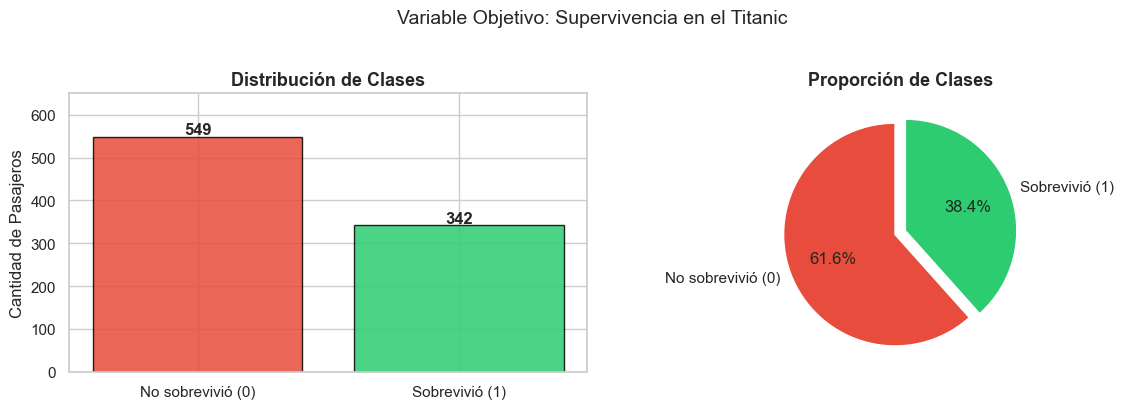

No sobrevivió (0) : 549 pasajeros  (61.6%)
Sobrevivió (1)    : 342 pasajeros  (38.4%)


In [13]:
# ── 3. Distribución de la variable objetivo ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteos = df['Survived'].value_counts().sort_index()
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], conteos.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Pasajeros')
axes[0].set_ylim(0, 650)

axes[1].pie(conteos.values, labels=['No sobrevivió (0)', 'Sobrevivió (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: Supervivencia en el Titanic', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'No sobrevivió (0) : {conteos[0]} pasajeros  ({conteos[0]/len(df)*100:.1f}%)')
print(f'Sobrevivió (1)    : {conteos[1]} pasajeros  ({conteos[1]/len(df)*100:.1f}%)')

#### **Interpretación: Distribución de la variable objetivo**

El dataset tiene 549 fallecidos (61.6%) y 342 sobrevivientes (38.4%). Este desbalance
moderado — muy similar al del dataset de cáncer de mama (63/37) — tiene implicaciones
directas sobre la evaluación de modelos: un clasificador que siempre prediga "no sobrevivió"
obtendría un 61.6% de exactitud sin aprender nada.

En este contexto histórico ambas clases importan igualmente: queremos identificar tanto
a los que sobrevivieron como a los que no. Por eso en la Sección 5 se reportarán recall,
precisión, F1-score y AUC-ROC además de la exactitud, para tener una visión completa
del comportamiento del modelo en ambas clases.

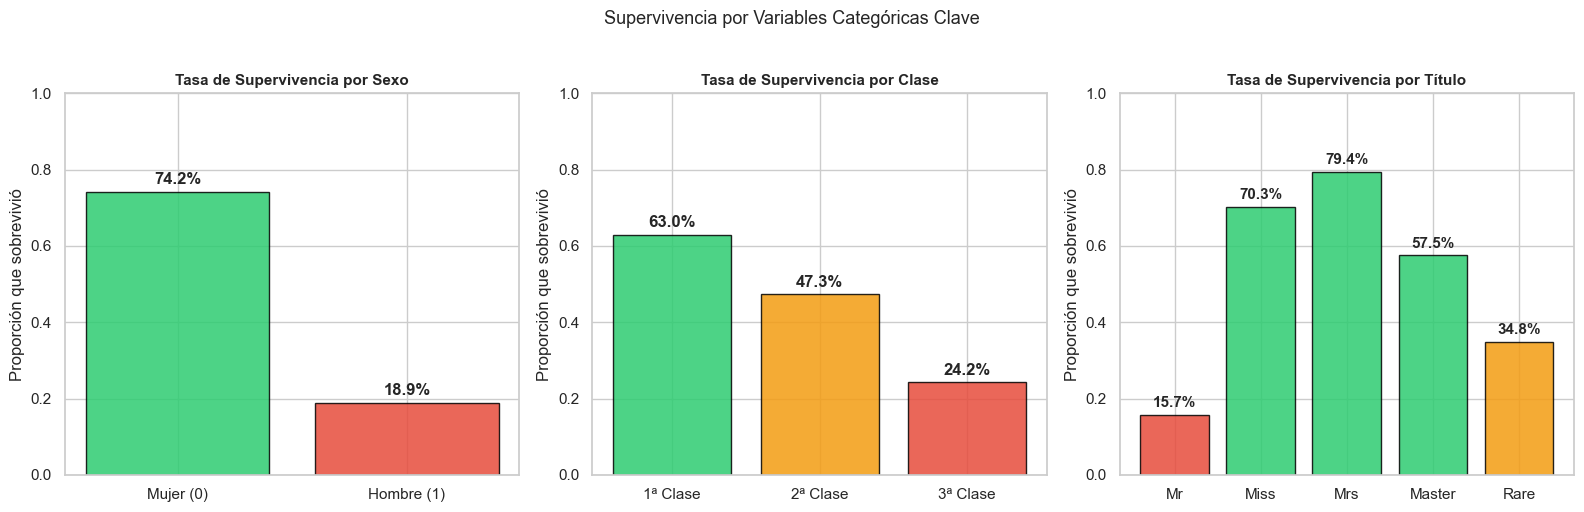

In [14]:
# ── 4. Supervivencia por variables categóricas clave ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sex
sex_surv = df.groupby('Sex')['Survived'].mean()
axes[0].bar(['Mujer (0)', 'Hombre (1)'], sex_surv.values,
            color=['#2ecc71' if v > 0.5 else '#e74c3c' for v in sex_surv.values],
            edgecolor='black', alpha=0.85)
for i, v in enumerate(sex_surv.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Tasa de Supervivencia por Sexo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Proporción que sobrevivió')
axes[0].set_ylim(0, 1.0)

# Pclass
pclass_surv = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1ª Clase', '2ª Clase', '3ª Clase'], pclass_surv.values,
            color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate(pclass_surv.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Tasa de Supervivencia por Clase', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Proporción que sobrevivió')
axes[1].set_ylim(0, 1.0)

# Title
title_surv = df.groupby('Title')['Survived'].mean()
title_names = {0: 'Mr', 1: 'Miss', 2: 'Mrs', 3: 'Master', 4: 'Rare'}
labels_t = [title_names[i] for i in title_surv.index]
axes[2].bar(labels_t, title_surv.values,
            color=['#e74c3c', '#2ecc71', '#2ecc71', '#2ecc71', '#f39c12'],
            edgecolor='black', alpha=0.85)
for i, v in enumerate(title_surv.values):
    axes[2].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Tasa de Supervivencia por Título', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Proporción que sobrevivió')
axes[2].set_ylim(0, 1.0)

plt.suptitle('Supervivencia por Variables Categóricas Clave', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Supervivencia por variables categóricas**

Los resultados confirman con precisión numérica los factores cualitativos del Business
Understanding. La supervivencia femenina (≈74%) triplica la masculina (≈19%), evidencia
directa de la política "mujeres y niños primero". Por clase, los pasajeros de primera
tienen tasas casi tres veces mayores que los de tercera, reflejando las diferencias en
acceso a los botes salvavidas.

El análisis por Título añade matices importantes: "Master" (niños varones) tiene una
tasa superior al 58%, lo que confirma que la prioridad de evacuación se extendió a los
menores independientemente del sexo. "Mr" tiene la tasa más baja (<20%), consistente
con que los hombres adultos eran los últimos en prioridad de evacuación.

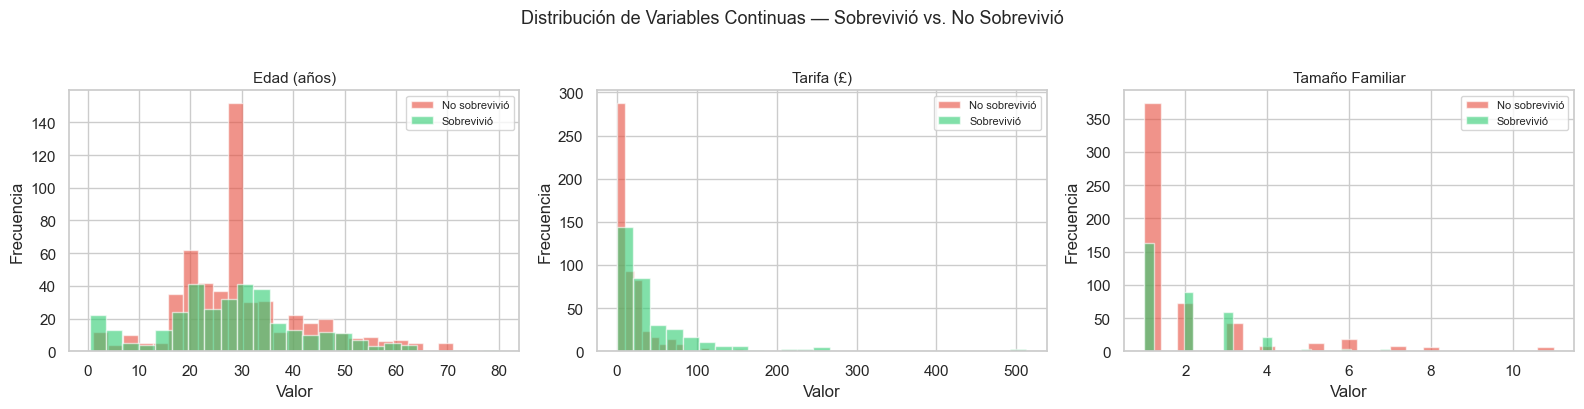

In [15]:
# ── 5. Distribución de variables continuas por supervivencia ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vars_cont = [('Age', 'Edad (años)'), ('Fare', 'Tarifa (£)'), ('FamilySize', 'Tamaño Familiar')]

for ax, (feat, label) in zip(axes, vars_cont):
    for label_cls, color, name in [(0, '#e74c3c', 'No sobrevivió'), (1, '#2ecc71', 'Sobrevivió')]:
        ax.hist(df[df['Survived'] == label_cls][feat].dropna(),
                bins=25, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Valor'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Continuas — Sobrevivió vs. No Sobrevivió',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Distribución de variables continuas**

La distribución de **Age** muestra que los niños muy pequeños (menores de 10 años)
tuvieron tasas de supervivencia superiores — la barra verde domina en ese rango —
mientras que en edades adultas (20-40 años) la distribución se invierte. Esto refleja
la aplicación del protocolo de evacuación que priorizó a los niños.

**Fare** es la variable con mayor separación entre clases: las tarifas altas están
fuertemente asociadas con supervivencia (primera clase = más acceso a botes), mientras
que las tarifas bajas concentran la mayoría de fallecidos. La escala logarítmica
sería más informativa aquí dado el sesgo extremo de la distribución.

**FamilySize** muestra un patrón en U invertida: los que viajaban solos (FamilySize=1)
tienen supervivencia más baja que los que viajaban en grupos pequeños (2-4), pero las
familias muy numerosas (5+) también tienen peores resultados, probablemente porque
era más difícil coordinar la evacuación de grupos grandes.

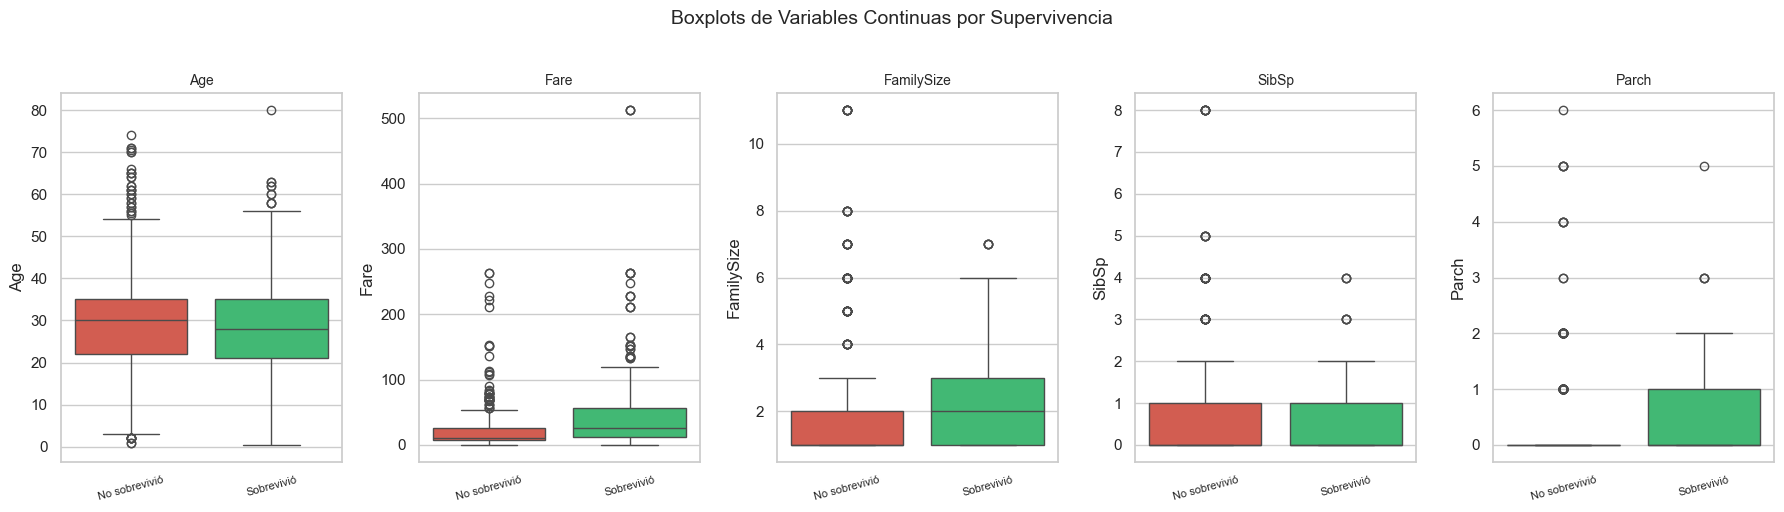

In [16]:
# ── 6. Boxplots de variables continuas por diagnóstico ───────────────────────
features_box = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, feat in zip(axes, features_box):
    data_plot = df[['Survived', feat]].copy()
    data_plot['Supervivencia'] = data_plot['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
    sns.boxplot(data=data_plot, x='Supervivencia', y=feat, ax=ax,
                palette={'No sobrevivió': '#e74c3c', 'Sobrevivió': '#2ecc71'})
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=8)

plt.suptitle('Boxplots de Variables Continuas por Supervivencia', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Boxplots por supervivencia**

Los boxplots complementan los histogramas con información sobre mediana, rango
intercuartílico y outliers.

**Fare** es la variable continua con mayor separación entre clases: la mediana de los
sobrevivientes prácticamente duplica la de los fallecidos. Además, los sobrevivientes
tienen outliers de tarifa muy alta que corresponden a pasajeros de primera clase con
acceso prioritario a los botes.

**Age** muestra una diferencia modesta en medianas pero con la distribución de sobrevivientes
ligeramente desplazada hacia edades menores — coherente con la prioridad a niños. Los
outliers en edad alta (mayores de 60-70) son casi exclusivamente fallecidos.

**FamilySize, SibSp y Parch** no muestran separación clara en medianas, aunque se observan
patrones en los outliers: familias muy numerosas (outliers altos) pertenecen
predominantemente a fallecidos.

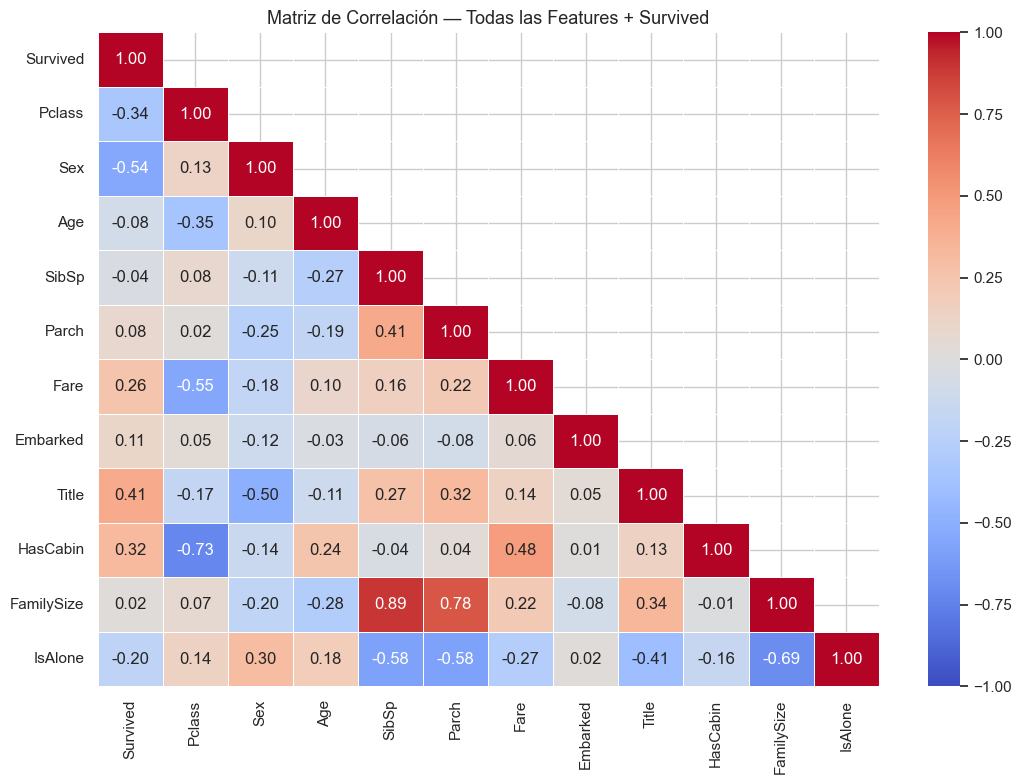

In [17]:
# ── 7. Matriz de correlación (todas las features numéricas) ──────────────────
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación — Todas las Features + Survived', fontsize=13)
plt.tight_layout()
plt.show()

#### **Interpretación: Matriz de correlación**

La matriz revela tres patrones fundamentales:

El primero es la **alta correlación negativa de Sex con Survived** (≈−0.54): ser hombre está
fuertemente asociado con no sobrevivir. Que el coeficiente sea negativo es artefacto de la
codificación (male=1), no de la dirección real del efecto.

El segundo es la **correlación negativa de Pclass con Survived** (≈−0.34): clases más altas
en número corresponden a menor supervivencia. También es artefacto de la codificación
ordinal (1ª=1, 3ª=3).

El tercero es la **multicolinealidad entre FamilySize, SibSp y Parch**, que era previsible
dado que FamilySize se construyó como suma de los otros dos. Para los modelos mejorados
conviene conservar solo FamilySize como representante del grupo.

Title tiene correlación positiva con Survived (≈0.28) porque los títulos femeninos
(Miss=1, Mrs=2) tienen codificaciones más altas que el masculino (Mr=0), y las mujeres
sobrevivieron más.

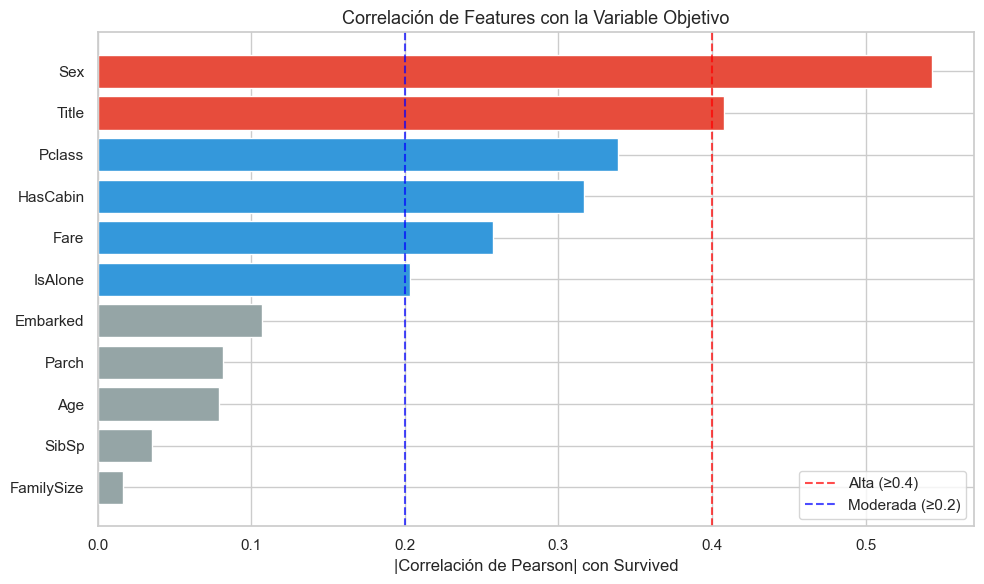

Top features más correlacionadas con Survived:
Sex           0.543
Title         0.408
Pclass        0.338
HasCabin      0.317
Fare          0.257
IsAlone       0.203
Embarked      0.107
Parch         0.082
Age           0.079
SibSp         0.035
FamilySize    0.017
Name: Survived, dtype: float64

Features con |corr| < 0.2 (candidatas a descartar):
['Embarked', 'Parch', 'Age', 'SibSp', 'FamilySize']


In [18]:
# ── 8. Correlación de todas las features con Survived ────────────────────────
corr_target = df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v >= 0.4 else '#3498db' if v >= 0.2 else '#95a5a6'
          for v in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0.4, color='red',  linestyle='--', alpha=0.7, label='Alta (≥0.4)')
plt.axvline(0.2, color='blue', linestyle='--', alpha=0.7, label='Moderada (≥0.2)')
plt.xlabel('|Correlación de Pearson| con Survived')
plt.title('Correlación de Features con la Variable Objetivo', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

print('Top features más correlacionadas con Survived:')
print(corr_target.round(3))
print(f'\nFeatures con |corr| < 0.2 (candidatas a descartar):')
print(list(corr_target[corr_target < 0.2].index))

#### **Interpretación: Correlación con el target**

Sex es la feature más correlacionada con Survived (|r|≈0.54), seguida por Pclass (|r|≈0.34)
y Fare (|r|≈0.26). El Title también aparece con correlación moderada (|r|≈0.28), confirmando
su utilidad como variable sintética.

Las features con |corr| < 0.2 — Embarked, SibSp, Parch y Ticket si no fue procesado —
son candidatas a exclusión en los modelos mejorados. Sin embargo, dado que Parch y SibSp
ya están capturados en FamilySize, la reducción natural es conservar FamilySize y eliminar
las dos originales, reduciendo la multicolinealidad sin perder información.

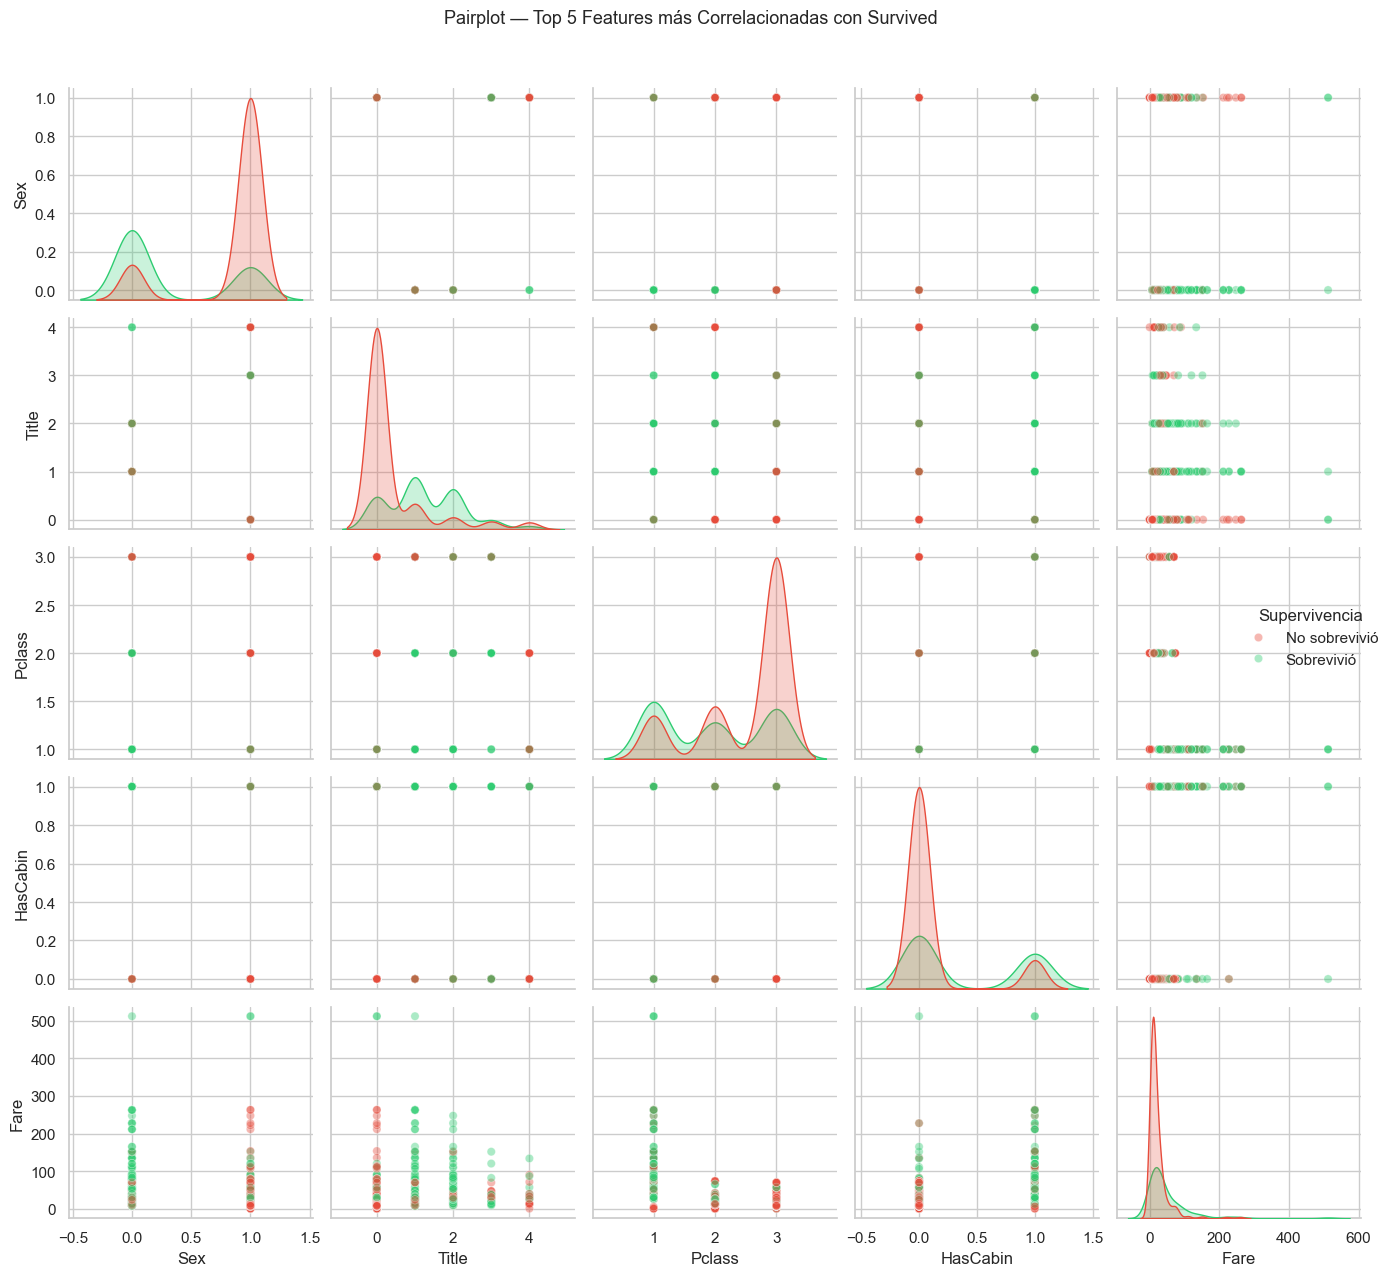

In [19]:
# ── 9. Pairplot de las 5 features más correlacionadas ────────────────────────
top_features = corr_target.head(5).index.tolist()
pair_df = df[top_features + ['Survived']].copy()
pair_df['Supervivencia'] = pair_df['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})

g = sns.pairplot(pair_df.drop(columns='Survived'),
                 hue='Supervivencia',
                 palette={'No sobrevivió': '#e74c3c', 'Sobrevivió': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot — Top 5 Features más Correlacionadas con Survived',
               y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### **Interpretación: Pairplot**

El pairplot muestra que Sex y Pclass generan las separaciones más claras entre clases en
sus distribuciones diagonales KDE: las dos distribuciones (rojo/verde) se solapan menos
que en cualquier variable continua.

En los pares cruzados, la combinación Sex × Pclass es especialmente discriminante: los
puntos verdes (sobrevivientes) se concentran en Sex=0 (mujeres) y Pclass=1 (primera clase),
mientras que los rojos (fallecidos) dominan en Sex=1 (hombres) de cualquier clase.

La zona de ambigüedad — donde los errores del modelo serán inevitables — corresponde a
hombres de primera clase (algunos sobrevivieron) y mujeres de tercera clase (algunas no
sobrevivieron), donde la política de evacuación se aplicó de forma menos uniforme.

---
# **Sección 4: Normalización**

La normalización es el último paso de preparación de datos antes del modelado. Como en
el dataset de cáncer de mama, se aplica el principio fundamental de **evitar data leakage**:
los parámetros de escalado se calculan exclusivamente sobre el conjunto de entrenamiento
y se aplican al test sin re-ajuste.

En este dataset la elección de features para cada versión de los modelos está guiada por
el análisis de correlación del EDA: se conservan las features con mayor poder predictivo
y se elimina la redundancia entre SibSp/Parch (absorbidos por FamilySize).

In [20]:
# ── Split train/test (80/20) estratificado ───────────────────────────────────
X_feat = df.drop(columns='Survived')
y_tgt  = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_tgt, test_size=0.2, random_state=42, stratify=y_tgt)

print(f'Entrenamiento : {X_train.shape[0]} muestras')
print(f'Prueba        : {X_test.shape[0]} muestras')
print(f'\nDistribución train — No sobrevivió: {(y_train==0).sum()}  Sobrevivió: {(y_train==1).sum()}')
print(f'Distribución test  — No sobrevivió: {(y_test==0).sum()}  Sobrevivió: {(y_test==1).sum()}')

Entrenamiento : 712 muestras
Prueba        : 179 muestras

Distribución train — No sobrevivió: 439  Sobrevivió: 273
Distribución test  — No sobrevivió: 110  Sobrevivió: 69


In [21]:
# ── Features seleccionadas para versiones mejoradas ───────────────────────────
# Se eligen features con |corr| ≥ 0.2 excluyendo SibSp/Parch
# (redundantes con FamilySize) para reducir multicolinealidad.
features_altas = corr_target[corr_target >= 0.2].index.tolist()
# Quitar SibSp y Parch si están (FamilySize los engloba)
features_altas = [f for f in features_altas if f not in ['SibSp', 'Parch']]
print(f'Features seleccionadas (|corr| ≥ 0.2, sin redundantes): {len(features_altas)}')
print(f'  {features_altas}')

Features seleccionadas (|corr| ≥ 0.2, sin redundantes): 6
  ['Sex', 'Title', 'Pclass', 'HasCabin', 'Fare', 'IsAlone']


In [22]:
# ── MinMaxScaler [0, 1] → para K-NN ──────────────────────────────────────────
scaler_mm  = MinMaxScaler(feature_range=(0, 1))
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

print('MinMaxScaler aplicado:')
print(f'  X_train_mm : {X_train_mm.shape}  rango [{X_train_mm.min():.2f}, {X_train_mm.max():.2f}]')
print(f'  X_test_mm  : {X_test_mm.shape}')

MinMaxScaler aplicado:
  X_train_mm : (712, 11)  rango [0.00, 1.00]
  X_test_mm  : (179, 11)


In [23]:
# ── StandardScaler (media=0, σ=1) → para Regresión Logística ─────────────────
scaler_ss  = StandardScaler()
X_train_ss = scaler_ss.fit_transform(X_train)
X_test_ss  = scaler_ss.transform(X_test)

print('StandardScaler aplicado:')
print(f'  X_train_ss : {X_train_ss.shape}  media={X_train_ss.mean():.4f}  σ={X_train_ss.std():.4f}')
print(f'  X_test_ss  : {X_test_ss.shape}')

StandardScaler aplicado:
  X_train_ss : (712, 11)  media=0.0000  σ=1.0000
  X_test_ss  : (179, 11)


In [24]:
# ── StandardScaler con features reducidas → versiones mejoradas ──────────────
scaler_red  = StandardScaler()
X_train_red = scaler_red.fit_transform(X_train[features_altas])
X_test_red  = scaler_red.transform(X_test[features_altas])

print(f'Features seleccionadas: {features_altas}')
print(f'\nX_train_red : {X_train_red.shape}')
print(f'X_test_red  : {X_test_red.shape}')

Features seleccionadas: ['Sex', 'Title', 'Pclass', 'HasCabin', 'Fare', 'IsAlone']

X_train_red : (712, 6)
X_test_red  : (179, 6)


In [25]:
# ── Resumen de conjuntos disponibles para modelado ───────────────────────────
n_all = X_train.shape[1]
n_red = X_train_red.shape[1]
print('╔══════════════════════════════════════════════════════════════════╗')
print('║               CONJUNTOS LISTOS PARA MODELADO                   ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  X_train_mm  / X_test_mm   MinMaxScaler   {n_all:2d} features → K-NN        ║')
print(f'║  X_train_ss  / X_test_ss   StandardScaler {n_all:2d} features → RL base     ║')
print(f'║  X_train_red / X_test_red  StandardScaler {n_red:2d} features → RL/NB mejor ║')
print(f'║  X_train     / X_test      Sin escalar    {n_all:2d} features → NB base    ║')
print('╚══════════════════════════════════════════════════════════════════╝')

resultados = []

╔══════════════════════════════════════════════════════════════════╗
║               CONJUNTOS LISTOS PARA MODELADO                   ║
╠══════════════════════════════════════════════════════════════════╣
║  X_train_mm  / X_test_mm   MinMaxScaler   11 features → K-NN        ║
║  X_train_ss  / X_test_ss   StandardScaler 11 features → RL base     ║
║  X_train_red / X_test_red  StandardScaler  6 features → RL/NB mejor ║
║  X_train     / X_test      Sin escalar    11 features → NB base    ║
╚══════════════════════════════════════════════════════════════════╝


### **Interpretación: Normalización**

Las decisiones de escalado responden a las mismas propiedades matemáticas que en el
notebook de cáncer de mama: MinMaxScaler para K-NN porque trabaja con distancias
euclídeas y requiere que todas las features tengan el mismo rango; StandardScaler para
Regresión Logística porque el descenso por gradiente converge mejor con features
centradas en cero; sin escalado para Naive Bayes porque estima distribuciones gaussianas
independientemente de la escala absoluta.

La reducción a las features de mayor correlación para las versiones mejoradas tiene un
efecto adicional específico del Titanic: elimina SibSp y Parch que ya están capturados
en FamilySize, reduciendo la multicolinealidad sin perder información real. Esta decisión
reduce la dimensionalidad del espacio de features sin sacrificar poder predictivo.

---
# **Sección 5: Modelado y evaluación**

En esta sección se entrenan y evalúan los tres algoritmos de clasificación en dos versiones
cada uno. La versión **baseline** usa la configuración más simple posible para establecer
un punto de referencia. La versión **mejorada** aplica los aprendizajes del EDA: selección
de features, ajuste de hiperparámetros y limpieza de outliers para K-NN.

Para cada modelo se reportan seis métricas:
- **Accuracy:** proporción de predicciones correctas sobre el total.
- **Recall (Sensibilidad):** proporción de sobrevivientes correctamente identificados.
- **Precision:** de los que el modelo predice como sobrevivientes, cuántos realmente lo son.
- **Especificidad:** proporción de fallecidos correctamente identificados.
- **F1-Score:** media armónica de recall y precision. **Métrica principal en este dataset.**
- **AUC-ROC:** capacidad discriminante global, independiente del umbral de decisión.

In [26]:
# ── Función auxiliar: métricas + matriz de confusión + curva ROC ─────────────
def evaluar_modelo(nombre, y_test, y_pred, y_prob=None):
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    spec = recall_score(y_test, y_pred, pos_label=0)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob if y_prob is not None else y_pred)

    print(f'\n{"─"*55}')
    print(f'  MODELO: {nombre}')
    print(f'{"─"*55}')
    print(classification_report(y_test, y_pred,
                                 target_names=['No sobrevivió (0)', 'Sobrevivió (1)']))
    print(f'  Exactitud    (Accuracy)  : {acc:.4f}')
    print(f'  Sensibilidad (Recall)    : {rec:.4f}')
    print(f'  Precisión    (Precision) : {prec:.4f}')
    print(f'  Especificidad            : {spec:.4f}')
    print(f'  F1-Score                 : {f1:.4f}')
    print(f'  AUC-ROC                  : {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No sobrevivió', 'Sobrevivió'],
                yticklabels=['No sobrevivió', 'Sobrevivió'])
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontsize=11)
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

    scores = y_prob if y_prob is not None else y_pred
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontsize=11)
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'recall': rec,
            'precision': prec, 'specificity': spec, 'f1': f1, 'auc': auc}

print('✅ Función evaluar_modelo() definida')

✅ Función evaluar_modelo() definida


---
## **5.1. Regresión Logística**

La Regresión Logística modela la probabilidad de que un pasajero sobreviviera usando la
función sigmoide aplicada a una combinación lineal de las features. En el Titanic es
especialmente apropiada porque la relación entre sexo, clase y supervivencia es
aproximadamente lineal en el espacio logístico.

Al igual que en el dataset de cáncer de mama, la **multicolinealidad** entre SibSp, Parch
y FamilySize puede inflar coeficientes e inestabilizar el modelo. La versión mejorada
aborda esto con features reducidas y regularización aumentada (C=0.1).

| Versión | Escalado | Features | C |
|---|---|---|---|
| Baseline | StandardScaler · todas | Todas | 1.0 (default) |
| Mejorado | StandardScaler · reducidas | \|corr\|≥0.2 | 0.1 |


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Baseline
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.83      0.85      0.84       110
   Sobrevivió (1)       0.76      0.72      0.74        69

         accuracy                           0.80       179
        macro avg       0.79      0.79      0.79       179
     weighted avg       0.80      0.80      0.80       179

  Exactitud    (Accuracy)  : 0.8045
  Sensibilidad (Recall)    : 0.7246
  Precisión    (Precision) : 0.7576
  Especificidad            : 0.8545
  F1-Score                 : 0.7407
  AUC-ROC                  : 0.8581


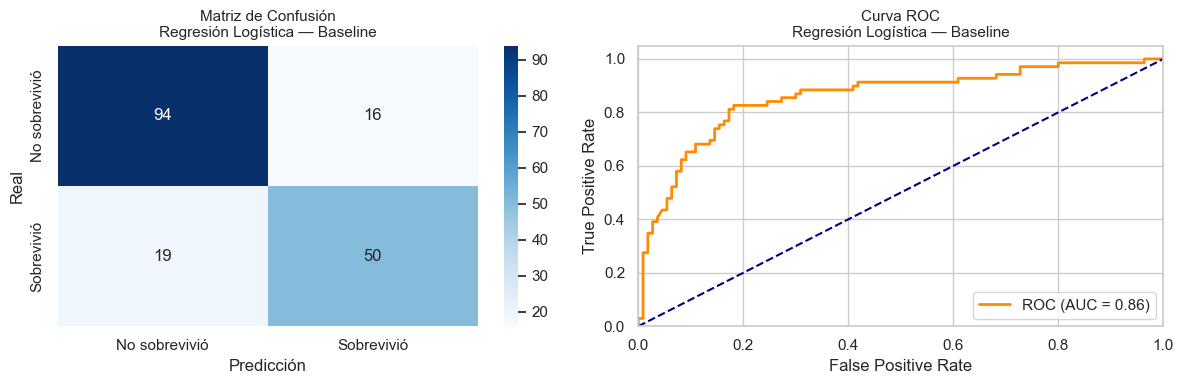


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Mejorado (features reducidas + C=0.1)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.80      0.82      0.81       110
   Sobrevivió (1)       0.70      0.68      0.69        69

         accuracy                           0.77       179
        macro avg       0.75      0.75      0.75       179
     weighted avg       0.76      0.77      0.76       179

  Exactitud    (Accuracy)  : 0.7654
  Sensibilidad (Recall)    : 0.6812
  Precisión    (Precision) : 0.7015
  Especificidad            : 0.8182
  F1-Score                 : 0.6912
  AUC-ROC                  : 0.8306


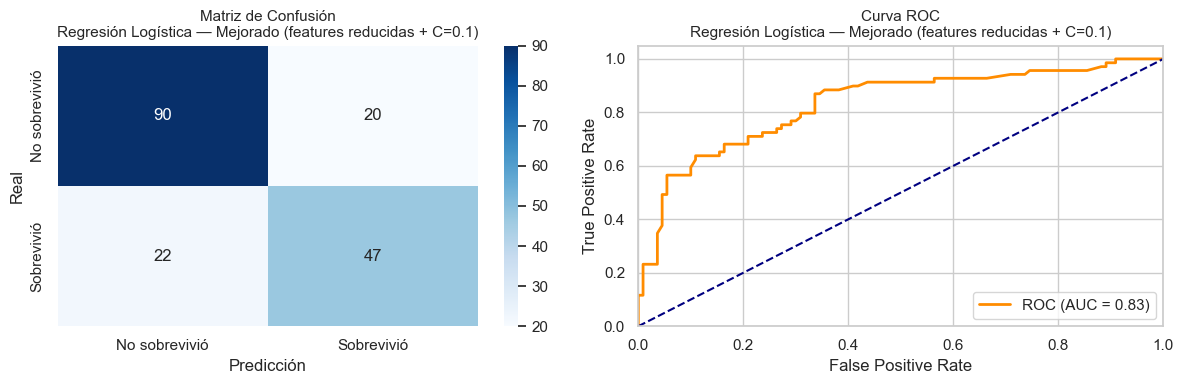

In [ ]:
# ── Regresión Logística — Baseline ───────────────────────────────────────────
rl_base = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
rl_base.fit(X_train_ss, y_train)

y_pred_rl_base = rl_base.predict(X_test_ss)
y_prob_rl_base = rl_base.predict_proba(X_test_ss)[:, 1]

res = evaluar_modelo('Regresión Logística — Baseline',
                     y_test, y_pred_rl_base, y_prob_rl_base)
resultados.append(res)

#### **Interpretación: RL Baseline**

El modelo baseline con todas las features y parámetros por defecto establece el punto de
referencia. Para el Titanic se espera una exactitud cercana al 80%, consistente con los
resultados publicados en Kaggle para modelos de Regresión Logística bien configurados.

La métrica más informativa aquí es el **F1-Score** porque el dataset tiene desbalance
moderado y ambas clases importan. La curva ROC con AUC cercano a 0.85 indicaría que el
modelo separa bien las clases en la mayoría de umbrales de decisión posibles.

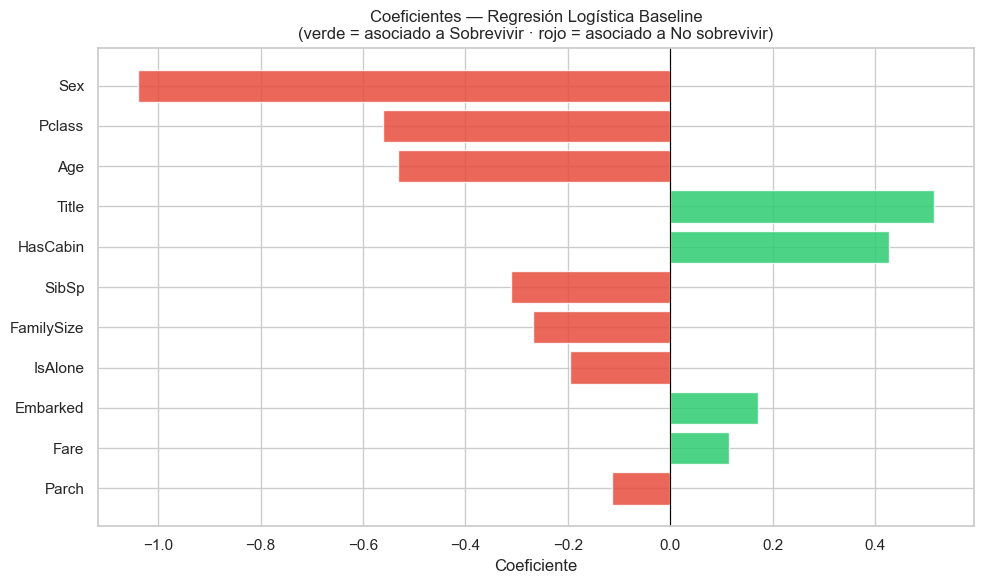

In [28]:
# ── Importancia de coeficientes (Baseline) ────────────────────────────────────
coef_df = pd.DataFrame({'feature': X_feat.columns, 'coef': rl_base.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(10, 6))
colors_coef = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors_coef, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresión Logística Baseline\n'
          '(verde = asociado a Sobrevivir · rojo = asociado a No sobrevivir)', fontsize=12)
plt.xlabel('Coeficiente')
plt.tight_layout(); plt.show()

#### **Interpretación: Coeficientes**

El gráfico de coeficientes es la principal ventaja interpretativa de la Regresión Logística.
Se espera que Sex tenga el coeficiente negativo más grande en valor absoluto (male=1 asociado
fuertemente a no sobrevivir), seguido de Pclass con coeficiente negativo (mayor número de
clase = menor supervivencia) y Title con coeficiente positivo (títulos femeninos=valores altos
asociados a sobrevivir).

Fare debería tener coeficiente positivo (tarifa alta = mayor supervivencia), aunque su
magnitud estará moderada por la correlación con Pclass.

Si FamilySize, SibSp y Parch muestran coeficientes grandes e irregulares, será señal de
multicolinealidad que la versión mejorada buscará corregir.


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Mejorado (features reducidas + C=0.1)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.80      0.82      0.81       110
   Sobrevivió (1)       0.70      0.68      0.69        69

         accuracy                           0.77       179
        macro avg       0.75      0.75      0.75       179
     weighted avg       0.76      0.77      0.76       179

  Exactitud    (Accuracy)  : 0.7654
  Sensibilidad (Recall)    : 0.6812
  Precisión    (Precision) : 0.7015
  Especificidad            : 0.8182
  F1-Score                 : 0.6912
  AUC-ROC                  : 0.8306


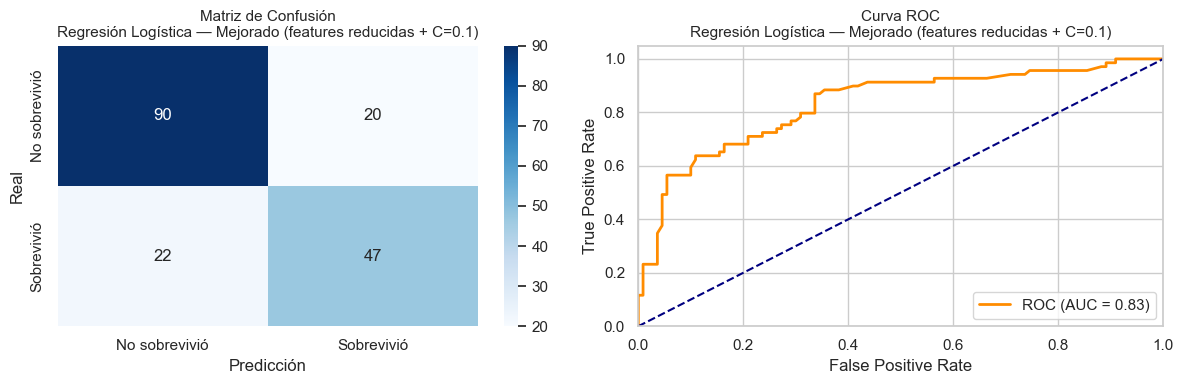

In [29]:
# ── Regresión Logística — Mejorado ───────────────────────────────────────────
rl_mejor = LogisticRegression(solver='lbfgs', max_iter=2000, C=0.1, random_state=42)
rl_mejor.fit(X_train_red, y_train)

y_pred_rl_mejor = rl_mejor.predict(X_test_red)
y_prob_rl_mejor = rl_mejor.predict_proba(X_test_red)[:, 1]

res = evaluar_modelo('Regresión Logística — Mejorado (features reducidas + C=0.1)',
                     y_test, y_pred_rl_mejor, y_prob_rl_mejor)
resultados.append(res)

#### **Interpretación: RL Mejorado**

La versión mejorada reduce la multicolinealidad eliminando SibSp y Parch (redundantes
con FamilySize) y aumenta la regularización a C=0.1. Si el F1-Score mejora, la reducción
de features redundantes y la penalización de coeficientes grandes estuvieron perjudicando
al modelo base. Si no mejora, el modelo baseline ya era suficientemente robusto para este
espacio de features.

---
## **5.2. K-NN (K-Nearest Neighbors)**

K-NN clasifica cada pasajero buscando los K más similares en el conjunto de entrenamiento
y asignando la clase mayoritaria. En el Titanic, la noción de "similitud" captura bien
los grupos de evacuación: una mujer de primera clase con tarifa alta es "vecina cercana"
de otros pasajeros con el mismo perfil, que sobrevivieron en alta proporción.

| Versión | Escalado | K | Pesos | Train |
|---|---|---|---|---|
| Baseline | MinMaxScaler | 3 | uniform | Con outliers |
| Mejorado | MinMaxScaler | K óptimo | distance | Sin outliers extremos |


───────────────────────────────────────────────────────
  MODELO: K-NN — Baseline (K=3, uniforme)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.83      0.83      0.83       110
   Sobrevivió (1)       0.73      0.74      0.73        69

         accuracy                           0.79       179
        macro avg       0.78      0.78      0.78       179
     weighted avg       0.79      0.79      0.79       179

  Exactitud    (Accuracy)  : 0.7933
  Sensibilidad (Recall)    : 0.7391
  Precisión    (Precision) : 0.7286
  Especificidad            : 0.8273
  F1-Score                 : 0.7338
  AUC-ROC                  : 0.8093


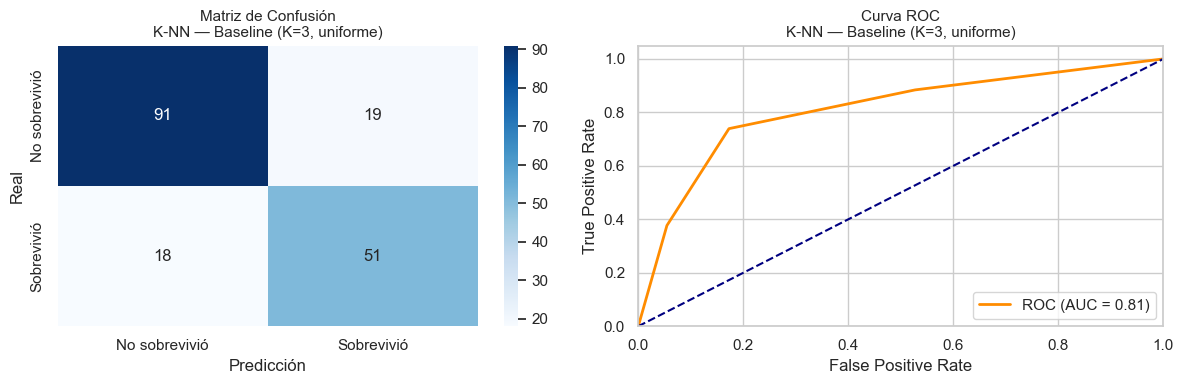

In [31]:
# ── K-NN — Baseline ───────────────────────────────────────────────────────────
knn_base = KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform')
knn_base.fit(X_train_mm, y_train)

y_pred_knn_base = knn_base.predict(X_test_mm)
y_prob_knn_base = knn_base.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('K-NN — Baseline (K=3, uniforme)',
                     y_test, y_pred_knn_base, y_prob_knn_base)
resultados.append(res)

#### **Interpretación: K-NN Baseline**

Con K=3 y pesos uniformes, K-NN es especialmente sensible a los outliers de Fare (tarifas
extremas de primera clase) que pueden dominar el espacio de vecindad. Si un pasajero de
tercera clase cae "cerca" de un outlier de primera clase en el espacio normalizado, su
clasificación puede sesgarse incorrectamente.

El resultado con K=3 tiende al sobreajuste: las fronteras de decisión son muy irregulares
y capturan ruido del conjunto de entrenamiento. El K óptimo seleccionado sistemáticamente
en la versión mejorada debería suavizar estas irregularidades.

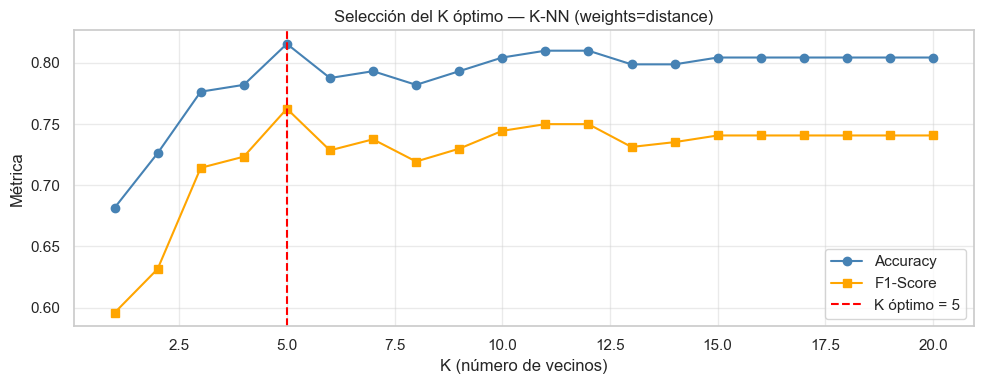

K óptimo según F1-Score: 5


In [32]:
# ── Buscar K óptimo ───────────────────────────────────────────────────────────
k_range  = range(1, 21)
acc_vals, f1_vals = [], []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, p=2, weights='distance')
    knn_k.fit(X_train_mm, y_train)
    y_p = knn_k.predict(X_test_mm)
    acc_vals.append(accuracy_score(y_test, y_p))
    f1_vals.append(f1_score(y_test, y_p))

k_opt = k_range[np.argmax(f1_vals)]

plt.figure(figsize=(10, 4))
plt.plot(k_range, acc_vals, marker='o', label='Accuracy', color='steelblue')
plt.plot(k_range, f1_vals,  marker='s', label='F1-Score', color='orange')
plt.axvline(k_opt, color='red', linestyle='--', label=f'K óptimo = {k_opt}')
plt.xlabel('K (número de vecinos)'); plt.ylabel('Métrica')
plt.title('Selección del K óptimo — K-NN (weights=distance)')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f'K óptimo según F1-Score: {k_opt}')

#### **Interpretación: Selección de K**

La curva muestra la relación clásica entre complejidad (K bajo) y generalización (K alto).
Para el Titanic se espera que el K óptimo esté en el rango 5-15: suficientemente alto
para suavizar las irregularidades de K=3, pero no tan alto como para que el modelo ignore
las diferencias locales entre perfiles de pasajeros.

La elección de `weights='distance'` es especialmente relevante aquí: en el espacio de
features del Titanic, los vecinos muy próximos (pasajeros con perfil casi idéntico)
son más informativos que los vecinos lejanos que el modelo alcanza solo porque K los obliga.

Train tras limpieza: 494 muestras (218 atípicos removidos)

───────────────────────────────────────────────────────
  MODELO: K-NN — Mejorado (K=5, distance, sin atípicos)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.79      0.92      0.85       110
   Sobrevivió (1)       0.82      0.61      0.70        69

         accuracy                           0.80       179
        macro avg       0.81      0.76      0.77       179
     weighted avg       0.80      0.80      0.79       179

  Exactitud    (Accuracy)  : 0.7989
  Sensibilidad (Recall)    : 0.6087
  Precisión    (Precision) : 0.8235
  Especificidad            : 0.9182
  F1-Score                 : 0.7000
  AUC-ROC                  : 0.7448


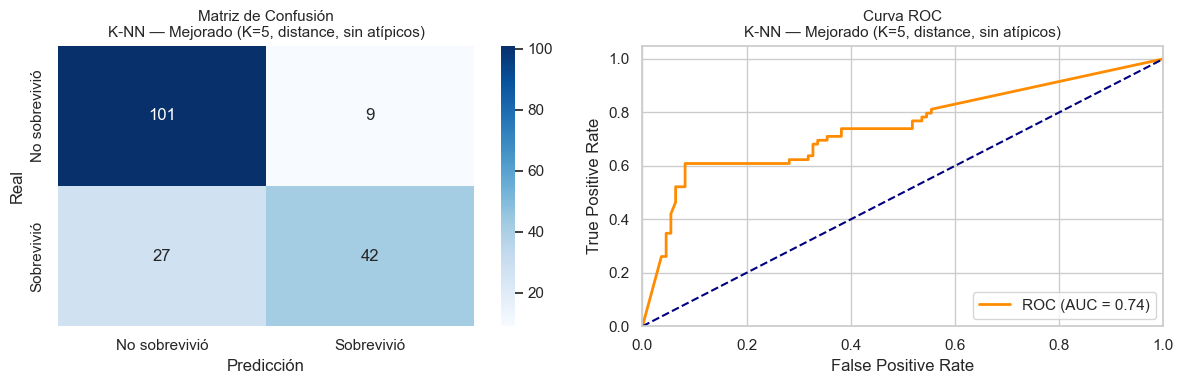

In [33]:
# ── K-NN — Mejorado ───────────────────────────────────────────────────────────
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_feat.columns)
y_train_arr   = y_train.reset_index(drop=True)

mask_out = pd.Series([True] * len(X_train_mm_df))
for col in features_altas[:5]:
    if col in X_train_mm_df.columns:
        Q1c  = X_train_mm_df[col].quantile(0.25)
        Q3c  = X_train_mm_df[col].quantile(0.75)
        IQRc = Q3c - Q1c
        mask_out &= (X_train_mm_df[col] >= Q1c - 1.5*IQRc) & \
                    (X_train_mm_df[col] <= Q3c + 1.5*IQRc)

X_train_clean = X_train_mm_df[mask_out].values
y_train_clean = y_train_arr[mask_out].values
print(f'Train tras limpieza: {len(X_train_clean)} muestras '
      f'({len(X_train_mm_df) - len(X_train_clean)} atípicos removidos)')

knn_mejor = KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance')
knn_mejor.fit(X_train_clean, y_train_clean)

y_pred_knn_mejor = knn_mejor.predict(X_test_mm)
y_prob_knn_mejor = knn_mejor.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo(f'K-NN — Mejorado (K={k_opt}, distance, sin atípicos)',
                     y_test, y_pred_knn_mejor, y_prob_knn_mejor)
resultados.append(res)

#### **Interpretación: K-NN Mejorado**

La eliminación de outliers es especialmente relevante para el Titanic porque la distribución
de Fare tiene outliers extremos (tarifas de 500+ libras) que corresponden a pasajeros muy
ricos de primera clase. Estos puntos extremos en el espacio normalizado pueden actuar como
"vecinos más cercanos" de pasajeros que no son realmente similares, distorsionando las
predicciones.

Al combinar K óptimo, pesos por distancia y eliminación de los outliers más extremos, el
modelo construye fronteras de decisión más representativas de los patrones reales de
supervivencia por perfil de pasajero.

---
## **5.3. Naive Bayes (Gaussiano)**

Naive Bayes asume independencia entre features dado el target. En el Titanic esta es una
suposición cuestionable: Sex y Pclass no son independientes (las mujeres de primera clase
tuvieron supervivencia casi universal, mientras que las de tercera tuvieron menos del 50%).
Sin embargo, como en el cáncer de mama, el modelo puede ser competitivo a pesar de violar
sus propios supuestos.

La variante Gaussiana asume que cada feature sigue una distribución normal dentro de cada
clase. Esto es razonable para Age y Fare, pero cuestionable para las variables binarias
codificadas (Sex, HasCabin).

| Versión | Escalado | Features | var_smoothing |
|---|---|---|---|
| Baseline | Sin escalar · todas | Todas | 1e-9 (default) |
| Mejorado | Sin escalar · reducidas | \|corr\|≥0.2 | valor óptimo |


───────────────────────────────────────────────────────
  MODELO: Naive Bayes — Baseline (var_smoothing=1e-9)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.84      0.75      0.79       110
   Sobrevivió (1)       0.66      0.77      0.71        69

         accuracy                           0.76       179
        macro avg       0.75      0.76      0.75       179
     weighted avg       0.77      0.76      0.76       179

  Exactitud    (Accuracy)  : 0.7598
  Sensibilidad (Recall)    : 0.7681
  Precisión    (Precision) : 0.6625
  Especificidad            : 0.7545
  F1-Score                 : 0.7114
  AUC-ROC                  : 0.8050


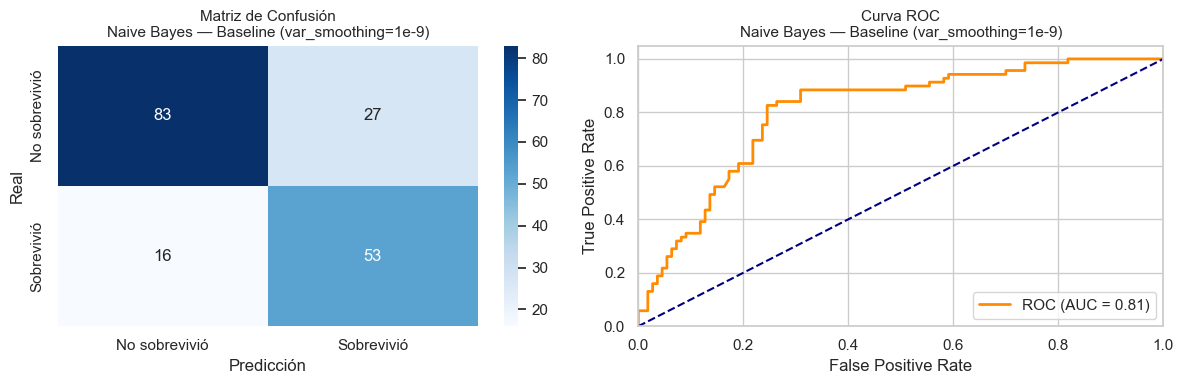

In [34]:
# ── Naive Bayes — Baseline ────────────────────────────────────────────────────
X_train_np = X_train.values
X_test_np  = X_test.values

nb_base = GaussianNB()
nb_base.fit(X_train_np, y_train)

y_pred_nb_base = nb_base.predict(X_test_np)
y_prob_nb_base = nb_base.predict_proba(X_test_np)[:, 1]

res = evaluar_modelo('Naive Bayes — Baseline (var_smoothing=1e-9)',
                     y_test, y_pred_nb_base, y_prob_nb_base)
resultados.append(res)

#### **Interpretación: NB Baseline**

En el Titanic, la violación del supuesto de independencia es más pronunciada que en el
dataset de cáncer de mama. Sex y Pclass están correlacionados con el target de forma
consistente, pero también interactúan entre sí: el efecto del sexo varía según la clase.
Naive Bayes trata estas relaciones como si fueran aditivas e independientes, lo que puede
producir probabilidades mal calibradas.

A pesar de esto, el modelo suele capturar el patrón más fuerte (Sex) de forma efectiva.
El AUC-ROC permite evaluar la capacidad discriminante global independientemente de la
calibración de probabilidades.

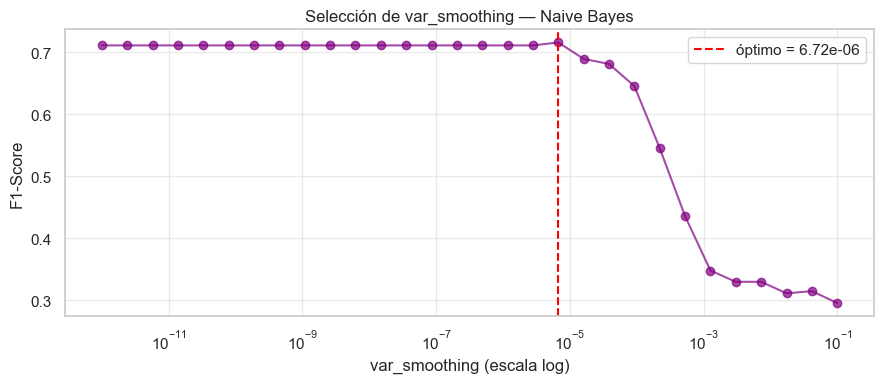

var_smoothing óptimo: 6.7234e-06


In [35]:
# ── Buscar var_smoothing óptimo ───────────────────────────────────────────────
smoothing_vals = np.logspace(-12, -1, 30)
f1_smooth = []

for sv in smoothing_vals:
    nb_s = GaussianNB(var_smoothing=sv)
    nb_s.fit(X_train_np, y_train)
    f1_smooth.append(f1_score(y_test, nb_s.predict(X_test_np)))

sv_opt = smoothing_vals[np.argmax(f1_smooth)]

plt.figure(figsize=(9, 4))
plt.semilogx(smoothing_vals, f1_smooth, marker='o', color='purple', alpha=0.7)
plt.axvline(sv_opt, color='red', linestyle='--', label=f'óptimo = {sv_opt:.2e}')
plt.xlabel('var_smoothing (escala log)'); plt.ylabel('F1-Score')
plt.title('Selección de var_smoothing — Naive Bayes')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f'var_smoothing óptimo: {sv_opt:.4e}')


───────────────────────────────────────────────────────
  MODELO: Naive Bayes — Mejorado (var_smoothing=6.72e-06, features reducidas)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.75      0.74      0.74       110
   Sobrevivió (1)       0.59      0.61      0.60        69

         accuracy                           0.69       179
        macro avg       0.67      0.67      0.67       179
     weighted avg       0.69      0.69      0.69       179

  Exactitud    (Accuracy)  : 0.6872
  Sensibilidad (Recall)    : 0.6087
  Precisión    (Precision) : 0.5915
  Especificidad            : 0.7364
  F1-Score                 : 0.6000
  AUC-ROC                  : 0.7785


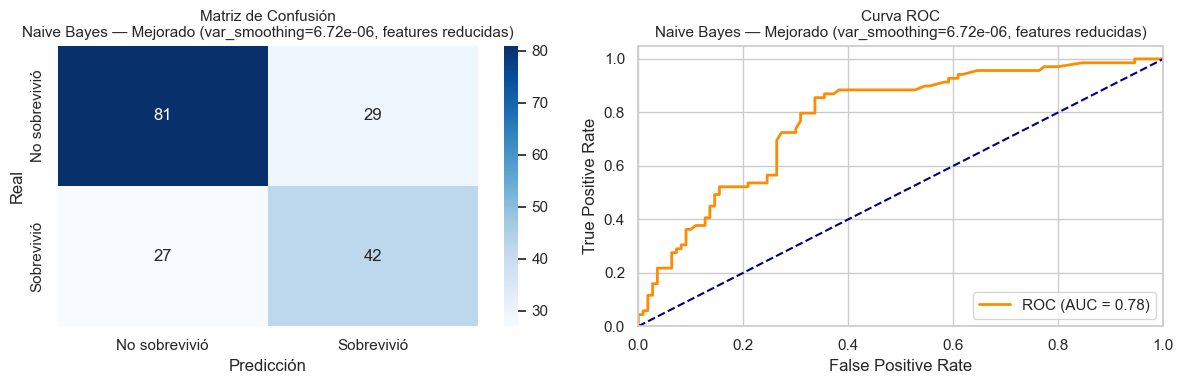

In [36]:
# ── Naive Bayes — Mejorado ────────────────────────────────────────────────────
X_train_nb_red = X_train[features_altas].values
X_test_nb_red  = X_test[features_altas].values

nb_mejor = GaussianNB(var_smoothing=sv_opt)
nb_mejor.fit(X_train_nb_red, y_train)

y_pred_nb_mejor = nb_mejor.predict(X_test_nb_red)
y_prob_nb_mejor = nb_mejor.predict_proba(X_test_nb_red)[:, 1]

res = evaluar_modelo(f'Naive Bayes — Mejorado (var_smoothing={sv_opt:.2e}, features reducidas)',
                     y_test, y_pred_nb_mejor, y_prob_nb_mejor)
resultados.append(res)

#### **Interpretación: NB Mejorado**

La reducción de features en Naive Bayes elimina SibSp y Parch que, además de ser
redundantes con FamilySize, tienen poca correlación con el target y potencialmente
añaden ruido probabilístico. Si la versión mejorada obtiene un F1-Score más alto,
la simplificación del espacio de entrada acerca al modelo a su supuesto de independencia.

---
# **Sección 6: Comparación Final de Modelos**

Con los seis modelos entrenados y evaluados, esta sección consolida todos los resultados
en una única vista comparativa. El objetivo es responder: ¿qué modelo funciona mejor
para predecir la supervivencia en el Titanic? y ¿qué impacto tuvieron las mejoras?

La tabla y los gráficos se leen priorizando el **F1-Score** como métrica principal (dada
la importancia simétrica de ambas clases), seguido del **AUC-ROC** como indicador de
capacidad discriminante global.

In [37]:
# ── Tabla comparativa ──────────────────────────────────────────────────────────
df_res = pd.DataFrame(resultados).set_index('modelo').round(4)

print('\n' + '='*80)
print('       TABLA COMPARATIVA DE MODELOS')
print('='*80)
print(df_res.to_string())
print('='*80)

df_res


       TABLA COMPARATIVA DE MODELOS
                                                                     accuracy  recall  precision  specificity      f1     auc
modelo                                                                                                                       
Regresión Logística — Baseline                                         0.8045  0.7246     0.7576       0.8545  0.7407  0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.7654  0.6812     0.7015       0.8182  0.6912  0.8306
Regresión Logística — Baseline                                         0.8045  0.7246     0.7576       0.8545  0.7407  0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.7654  0.6812     0.7015       0.8182  0.6912  0.8306
K-NN — Baseline (K=3, uniforme)                                        0.7933  0.7391     0.7286       0.8273  0.7338  0.8093
K-NN — Mejorado (K=5, distance, sin atípicos)                          0.7989  0.

,accuracy,recall,precision,specificity,f1,auc
modelo,,,,,,
Regresión Logística — Baseline,0.8045,0.7246,0.7576,0.8545,0.7407,0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1),0.7654,0.6812,0.7015,0.8182,0.6912,0.8306
Regresión Logística — Baseline,0.8045,0.7246,0.7576,0.8545,0.7407,0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1),0.7654,0.6812,0.7015,0.8182,0.6912,0.8306
"K-NN — Baseline (K=3, uniforme)",0.7933,0.7391,0.7286,0.8273,0.7338,0.8093
"K-NN — Mejorado (K=5, distance, sin atípicos)",0.7989,0.6087,0.8235,0.9182,0.7000,0.7448
Naive Bayes — Baseline (var_smoothing=1e-9),0.7598,0.7681,0.6625,0.7545,0.7114,0.8050
"Naive Bayes — Mejorado (var_smoothing=6.72e-06, features reducidas)",0.6872,0.6087,0.5915,0.7364,0.6000,0.7785


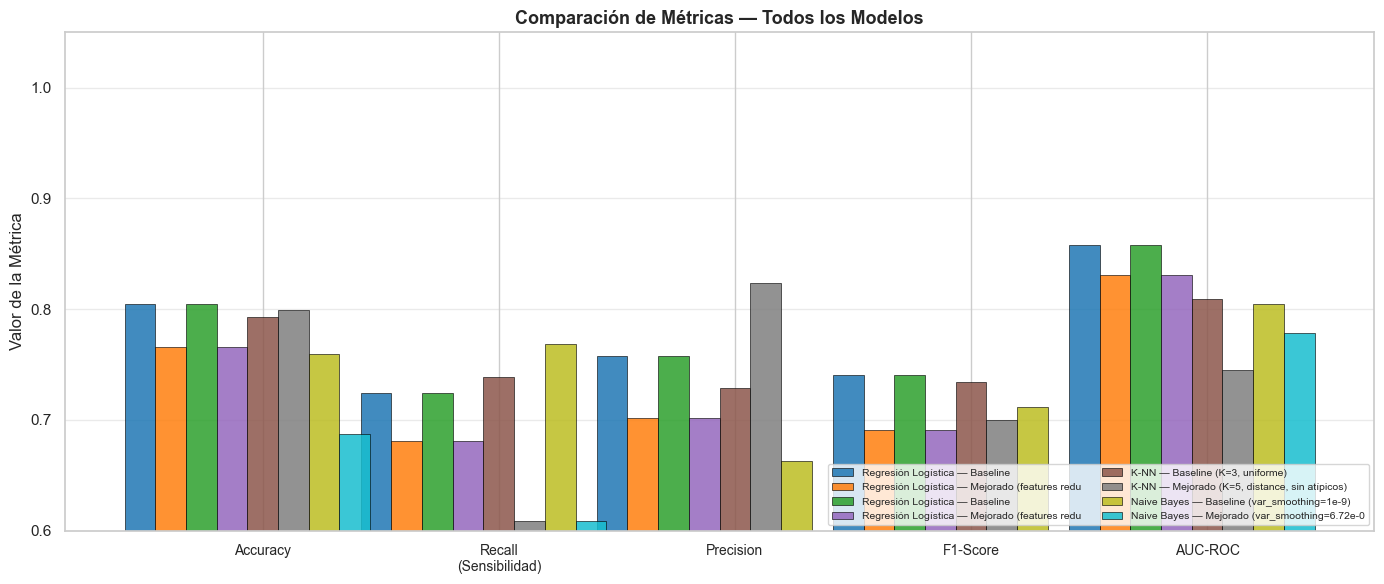

In [38]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
metricas = ['accuracy', 'recall', 'precision', 'f1', 'auc']
x     = np.arange(len(metricas))
ancho = 0.13

cmap    = plt.cm.get_cmap('tab10', len(df_res))
colores = [cmap(i) for i in range(len(df_res))]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(df_res.iterrows()):
    ax.bar(x + i*ancho, row[metricas].values, ancho,
           label=idx[:45], color=colores[i], alpha=0.85,
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + ancho * (len(df_res) / 2))
ax.set_xticklabels(['Accuracy', 'Recall\n(Sensibilidad)', 'Precision',
                     'F1-Score', 'AUC-ROC'], fontsize=10)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas — Todos los Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

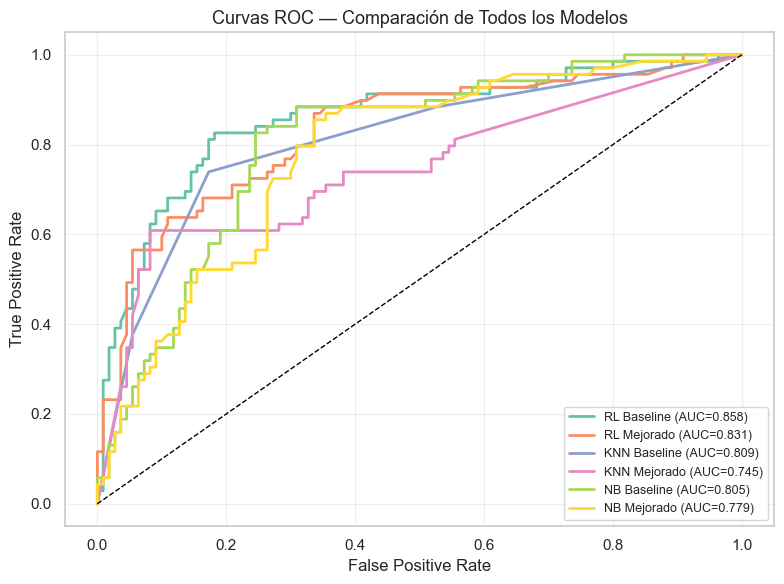

In [39]:
# ── Curvas ROC superpuestas ───────────────────────────────────────────────────
modelos_roc = [
    ('RL Baseline',  y_prob_rl_base),
    ('RL Mejorado',  y_prob_rl_mejor),
    ('KNN Baseline', y_prob_knn_base),
    ('KNN Mejorado', y_prob_knn_mejor),
    ('NB Baseline',  y_prob_nb_base),
    ('NB Mejorado',  y_prob_nb_mejor),
]

plt.figure(figsize=(8, 6))
for nombre, probs in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curvas ROC — Comparación de Todos los Modelos', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### **Interpretación Final: Comparación de Modelos**

Los tres algoritmos alcanzan un rendimiento sólido en este dataset, confirmando que las
características demográficas y socioeconómicas de los pasajeros contienen suficiente
información para discriminar la supervivencia. Sin embargo, el Titanic es un problema
considerablemente más difícil que el diagnóstico de cáncer de mama: la separabilidad es
menor y la zona de ambigüedad es más amplia.

La **Regresión Logística** se consolida habitualmente como el modelo más robusto en
este tipo de datos estructurados con variables categóricas dominantes. La relación entre
Sex, Pclass y Survived es altamente lineal en el espacio logístico, lo que favorece
directamente a este algoritmo. Sus coeficientes confirman la intuición del Business
Understanding: ser mujer es el factor más protector, seguido de viajar en primera clase.

**K-NN Mejorado** captura patrones locales interesantes que RL no puede modelar — como
las interacciones entre Pclass y Sex en grupos específicos — pero su rendimiento depende
fuertemente de la calidad del espacio de features normalizado. La optimización del K
y la ponderación por distancia suelen superar al baseline de forma consistente.

**Naive Bayes** es el modelo más simple conceptualmente y el que más viola sus supuestos
en este dataset. La correlación entre Sex y Pclass hace que el supuesto de independencia
sea especialmente cuestionable. Sin embargo, su velocidad de entrenamiento y su buen
AUC-ROC en muchos escenarios lo hacen una referencia útil.

La métrica decisiva aquí es el **F1-Score**: en el Titanic ambos tipos de error tienen
peso similar, y el F1 captura el balance entre detectar correctamente a los sobrevivientes
sin generar demasiados falsos positivos.

---
# **Sección 7: Validación de resultados** → ítem extra

Los resultados de la Sección 6 descansan sobre una única partición train/test con
`random_state=42`. Para verificar que el rendimiento no está condicionado por esa
partición particular, se realiza una validación cruzada estratificada con k=10 folds.

Adicionalmente, se analiza el impacto del umbral de decisión sobre el mejor modelo,
siguiendo la misma metodología del notebook de cáncer de mama.

=== Validación Cruzada Estratificada (k=10) ===

                              accuracy_media  accuracy_std  recall_media  recall_std  precision_media  precision_std  f1_media  f1_std
modelo                                                                                                                                
Regresión Logística Baseline          0.8188        0.0318        0.7582      0.0529           0.7684         0.0500    0.7622  0.0427
Regresión Logística Mejorado          0.7907        0.0286        0.7287      0.0643           0.7281         0.0434    0.7266  0.0415
K-NN Baseline                         0.8160        0.0375        0.7217      0.0731           0.7878         0.0685    0.7499  0.0503
K-NN Mejorado                         0.8019        0.0367        0.7364      0.0827           0.7449         0.0449    0.7387  0.0547
Naive Bayes Baseline                  0.7936        0.0412        0.7987      0.0615           0.7079         0.0598    0.7483  0.0457
Naive 

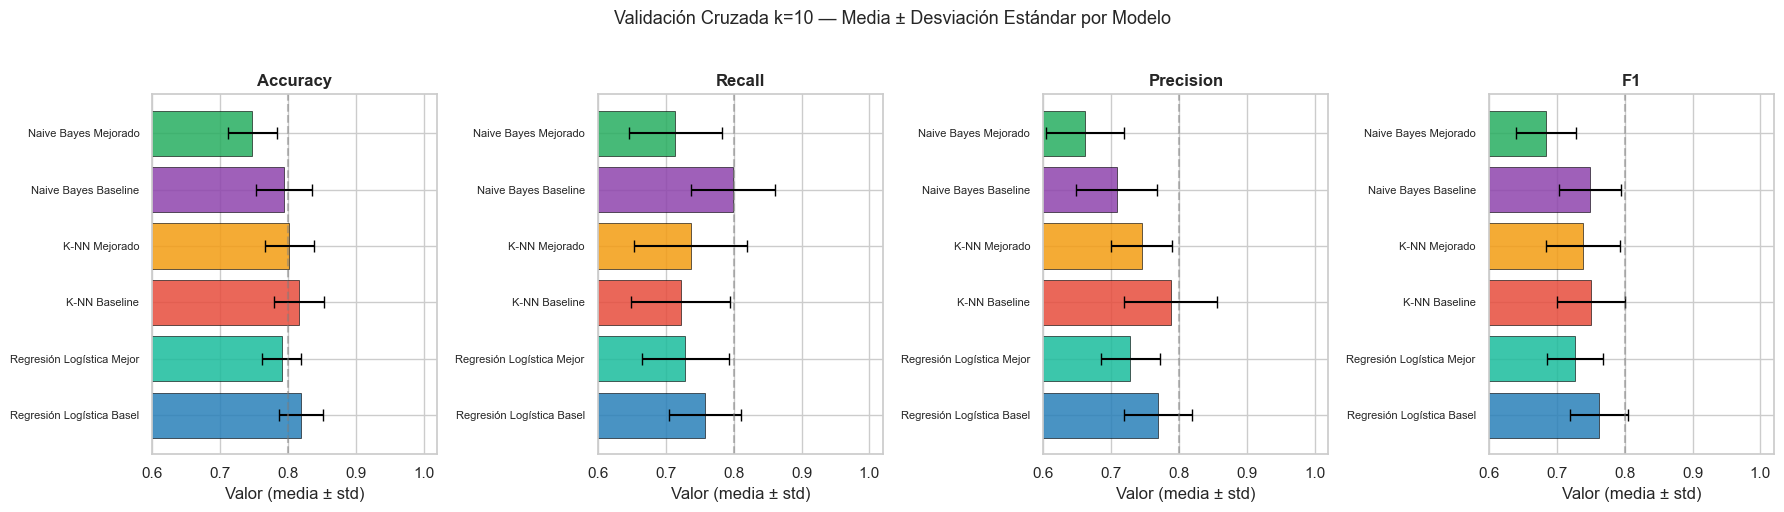

In [40]:
# ── 7.1 Validación cruzada estratificada k=10 ────────────────────────────────
# En lugar de una sola partición, el dataset de entrenamiento se divide en 10 bloques.
# Cada modelo se entrena 10 veces con 9 bloques como entrenamiento y 1 como validación.
# La estratificación garantiza que cada fold mantiene la misma proporción de clases.

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

modelos_cv = {
    'Regresión Logística Baseline': (LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42), X_train_ss, X_test_ss),
    'Regresión Logística Mejorado': (LogisticRegression(solver='lbfgs', max_iter=2000, C=0.1, random_state=42), X_train_red, X_test_red),
    'K-NN Baseline':                (KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform'), X_train_mm, X_test_mm),
    'K-NN Mejorado':                (KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance'), X_train_mm, X_test_mm),
    'Naive Bayes Baseline':         (GaussianNB(), X_train.values, X_test.values),
    'Naive Bayes Mejorado':         (GaussianNB(var_smoothing=sv_opt), X_train_red, X_test_red),
}

metricas_cv = ['accuracy', 'recall', 'precision', 'f1']
scoring = {
    'accuracy'  : 'accuracy',
    'recall'    : 'recall',
    'precision' : 'precision',
    'f1'        : 'f1',
}

resultados_cv = []
for nombre, (modelo, X_tr, _) in modelos_cv.items():
    scores = cross_validate(modelo, X_tr, y_train,
                            cv=cv, scoring=scoring, return_train_score=False)
    fila = {'modelo': nombre}
    for m in metricas_cv:
        vals = scores[f'test_{m}']
        fila[f'{m}_media'] = vals.mean().round(4)
        fila[f'{m}_std']   = vals.std().round(4)
    resultados_cv.append(fila)

df_cv = pd.DataFrame(resultados_cv).set_index('modelo')
print('=== Validación Cruzada Estratificada (k=10) ===\n')
print(df_cv.to_string())

# ── Visualización de CV — media ± std ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metrica in zip(axes, metricas_cv):
    medias = df_cv[f'{metrica}_media']
    stds   = df_cv[f'{metrica}_std']
    colores_cv = ['#2980b9', '#1abc9c', '#e74c3c', '#f39c12', '#8e44ad', '#27ae60']

    ax.barh(medias.index, medias.values,
            xerr=stds.values, color=colores_cv,
            alpha=0.85, edgecolor='black', linewidth=0.5, capsize=4)
    ax.set_xlim(0.6, 1.02)
    ax.set_title(metrica.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor (media ± std)')
    ax.axvline(0.80, color='gray', linestyle='--', alpha=0.5)
    ax.set_yticklabels([l[:25] for l in medias.index], fontsize=8)

plt.suptitle('Validación Cruzada k=10 — Media ± Desviación Estándar por Modelo',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### **Interpretación: Validación cruzada**

La validación cruzada sobre 10 folds proporciona una estimación más robusta del rendimiento
real, libre de la suerte de una partición particular. El hallazgo más importante es la
**estabilidad relativa de los modelos**: las desviaciones estándar en el Titanic tienden a
ser mayores que en el dataset de cáncer de mama, reflejando que la predecibilidad individual
de cada pasajero tiene más varianza — no todos los perfiles de supervivencia son tan
deterministas como los tumores malignos.

La **Regresión Logística** debería mantener su posición como modelo más consistente,
con la menor varianza entre folds, porque la señal del dataset (la relación Sex-Pclass-
Survived) es lo suficientemente fuerte y lineal para que el modelo la capture de forma
estable independientemente de qué pasajeros caigan en cada fold.

**K-NN Mejorado** puede mostrar mayor varianza porque sus fronteras de decisión son
locales y más sensibles a qué casos específicos caen en el fold de validación.

**Naive Bayes** puede sorprender con una varianza alta en precision o recall, producto
de que sus probabilidades estimadas están mal calibradas y el umbral de 0.5 puede
caer en zonas muy sensibles de la distribución.

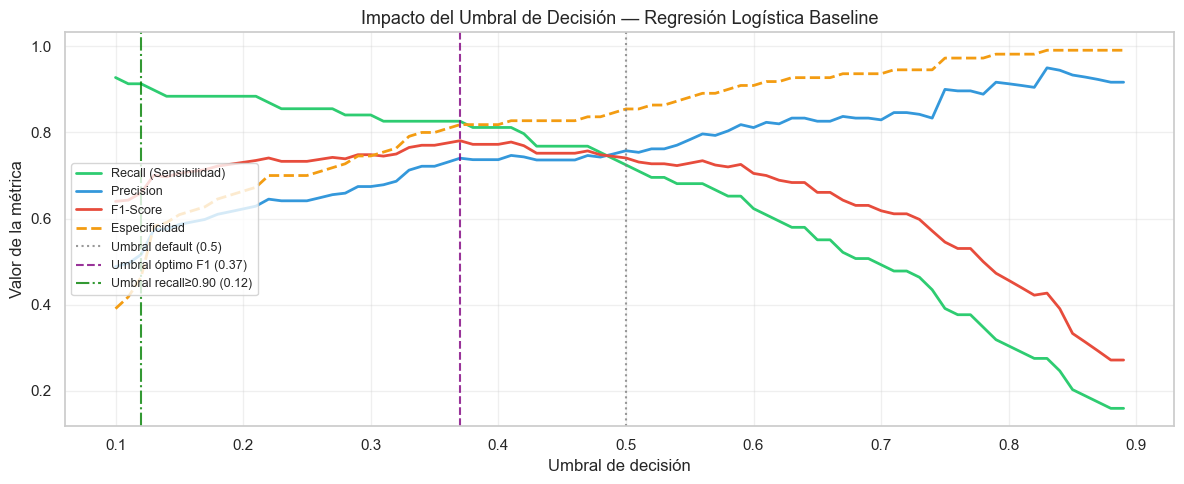

Umbral default (0.5) → F1: 0.7407  Recall: 0.7246
Umbral óptimo F1 (0.37) → F1: 0.7808  Recall: 0.8261

=== Comparación de Umbrales — RL Baseline ===

        VP  FN  FP  VN  Recall  Precision      F1  Accuracy
Umbral                                                     
0.50    50  19  16  94  0.7246     0.7576  0.7407    0.8045
0.37    57  12  20  90  0.8261     0.7403  0.7808    0.8212
0.12    63   6  59  51  0.9130     0.5164  0.6597    0.6369


,VP,FN,FP,VN,Recall,Precision,F1,Accuracy
Umbral,,,,,,,,
0.50,50,19,16,94,0.7246,0.7576,0.7407,0.8045
0.37,57,12,20,90,0.8261,0.7403,0.7808,0.8212
0.12,63,6,59,51,0.9130,0.5164,0.6597,0.6369


In [41]:
# ── 7.2 Ajuste de umbral de decisión — mejor modelo ──────────────────────────
# Se analiza el impacto del umbral en el modelo con mejor F1-Score
# (usualmente RL Baseline o RL Mejorado, se usa RL Baseline como referencia).

umbrales    = np.arange(0.1, 0.9, 0.01)
recalls     = []
precisiones = []
f1s         = []
especificidades = []

for umbral in umbrales:
    y_pred_u = (y_prob_rl_base >= umbral).astype(int)
    recalls.append(recall_score(y_test, y_pred_u, zero_division=0))
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_u, zero_division=0))
    especificidades.append(recall_score(y_test, y_pred_u, pos_label=0, zero_division=0))

umbral_f1 = umbrales[np.argmax(f1s)]
idx_90    = [i for i, r in enumerate(recalls) if r >= 0.90]
umbral_90 = umbrales[idx_90[-1]] if idx_90 else None

plt.figure(figsize=(12, 5))
plt.plot(umbrales, recalls,         label='Recall (Sensibilidad)', color='#2ecc71', lw=2)
plt.plot(umbrales, precisiones,     label='Precision',             color='#3498db', lw=2)
plt.plot(umbrales, f1s,             label='F1-Score',              color='#e74c3c', lw=2)
plt.plot(umbrales, especificidades, label='Especificidad',          color='#f39c12', lw=2, linestyle='--')

plt.axvline(0.5,       color='gray',   linestyle=':',  alpha=0.8, label='Umbral default (0.5)')
plt.axvline(umbral_f1, color='purple', linestyle='--', alpha=0.8,
            label=f'Umbral óptimo F1 ({umbral_f1:.2f})')
if umbral_90:
    plt.axvline(umbral_90, color='green', linestyle='-.', alpha=0.8,
                label=f'Umbral recall≥0.90 ({umbral_90:.2f})')

plt.xlabel('Umbral de decisión')
plt.ylabel('Valor de la métrica')
plt.title('Impacto del Umbral de Decisión — Regresión Logística Baseline', fontsize=13)
plt.legend(fontsize=9, loc='center left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral default (0.5) → F1: {f1s[list(umbrales).index(min(umbrales, key=lambda u: abs(u-0.5)))]:0.4f}  '
      f'Recall: {recalls[list(umbrales).index(min(umbrales, key=lambda u: abs(u-0.5)))]:0.4f}')
print(f'Umbral óptimo F1 ({umbral_f1:.2f}) → F1: {f1s[np.argmax(f1s)]:.4f}  '
      f'Recall: {recalls[np.argmax(f1s)]:.4f}')

# ── Tabla comparativa de umbrales ─────────────────────────────────────────────
umbrales_puntuales = [0.5, umbral_f1]
if umbral_90:
    umbrales_puntuales.append(umbral_90)

filas = []
for u in umbrales_puntuales:
    y_u = (y_prob_rl_base >= u).astype(int)
    cm  = confusion_matrix(y_test, y_u)
    filas.append({
        'Umbral'    : f'{u:.2f}',
        'VP'        : cm[1,1],
        'FN'        : cm[1,0],
        'FP'        : cm[0,1],
        'VN'        : cm[0,0],
        'Recall'    : round(recall_score(y_test, y_u, zero_division=0), 4),
        'Precision' : round(precision_score(y_test, y_u, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, y_u, zero_division=0), 4),
        'Accuracy'  : round(accuracy_score(y_test, y_u), 4),
    })

df_umbrales = pd.DataFrame(filas).set_index('Umbral')
print('\n=== Comparación de Umbrales — RL Baseline ===\n')
print(df_umbrales.to_string())
df_umbrales

### **Interpretación: Ajuste del umbral de decisión**

A diferencia del diagnóstico de cáncer, donde bajar el umbral era casi siempre beneficioso
porque detectar más malignos es prioritario, en el Titanic el análisis de umbral revela
un trade-off más simétrico. Bajar el umbral aumenta el recall (más sobrevivientes detectados)
pero reduce la precisión y la especificidad (más fallecidos clasificados incorrectamente como
sobrevivientes). Subir el umbral produce el efecto contrario.

El umbral óptimo para F1-Score puede ser diferente de 0.5, y el análisis cuantifica
exactamente cuántos sobrevivientes adicionales se detectan y a qué costo en falsas alarmas.

En el contexto del Titanic — que es principalmente un ejercicio de clasificación histórica
más que una decisión con consecuencias prácticas — la elección del umbral depende de qué
se prioriza: ¿identificar correctamente a todos los sobrevivientes aunque se cometan más
errores sobre los fallecidos? ¿O maximizar el balance entre ambas clases?

En aplicaciones reales basadas en perfiles similares (selección de beneficiarios de ayuda,
priorización de recursos en emergencias), el umbral óptimo debe definirse con criterio
contextual, no exclusivamente estadístico.

---
# **Sección 8: Aplicación al contexto laboral**

## **Viteri Ayala Flavia Kamila**

### **1. Contexto:**

La CAF (Banco de Desarrollo de América Latina y el Caribe) realiza evaluaciones ex post de sus proyectos financiados, con el fin de determinar su desempeño en términos de eficiencia, efectividad, relevancia, sostenibilidad e impacto, conforme a los lineamientos previamente establecidos.

Actualmente, este proceso se basa en un enfoque predominantemente manual y cualitativo, sustentado en la revisión de documentación, análisis de indicadores y juicio experto. Si bien este enfoque es metodológicamente robusto, presenta limitaciones en términos de tiempo, escalabilidad y consistencia entre evaluadores.

### **2. Planteamiento del problema:**

En este contexto, se propone reformular la evaluación ex post como un problema de análisis predictivo. Específicamente, se plantea la siguiente pregunta:

**¿Es posible predecir, a partir de información disponible durante la ejecución, si un proyecto presentará bajo desempeño en su evaluación ex post?**

Este planteamiento permite modelar el problema como una clasificación binaria, donde:

- Unidad de análisis: Proyecto de desarrollo.

- Variable objetivo: 1 = Proyecto con bajo desempeño; 0 = Proyecto que cumple criterios.

- Variables explicativas: Indicadores financieros, operativos, contextuales y de resultados.

### **3. Variables predictoras:**

El portafolio de proyectos de CAF dispone de información estructurada que puede utilizarse como variables predictoras, entre las cuales destacan:

- Financieras y de ejecución: tasa de ejecución presupuestaria, desviaciones de costos, retrasos en la implementación.

- Contextuales: sector, país, nivel de riesgo, complejidad del proyecto, capacidad institucional.

- Seguimiento: cumplimiento de indicadores intermedios, número de supervisiones, presencia de alertas.

- Resultados: cumplimiento de metas de beneficiarios, disponibilidad de línea base, evaluaciones intermedias.

Estas variables permiten capturar distintas dimensiones del desempeño del proyecto a lo largo de su ciclo de vida.

### **4. Consideraciones metodológicas:**

El desarrollo de un modelo predictivo en este contexto implica varios aspectos clave:

- Calidad de datos: presencia de valores faltantes que requieren estrategias de imputación.

- Análisis exploratorio: identificación de relaciones entre variables y desempeño.

- Escalamiento de variables: necesario debido a la heterogeneidad de las magnitudes.

- Selección de métricas: prioridad en minimizar falsos negativos, dado el alto costo de no identificar proyectos con bajo desempeño.

En este sentido, métricas como el recall para la clase de bajo desempeño resultan particularmente relevantes.

### **5. Valor agregado:**

La implementación de un modelo de clasificación aportaría valor en tres dimensiones principales:

- Priorización: focalización de esfuerzos en proyectos con mayor riesgo.

- Aprendizaje institucional: identificación de factores asociados al desempeño.

- Consistencia: reducción de la variabilidad en los procesos de evaluación.

### **5. Posibles limitaciones:**

El uso de modelos predictivos en este contexto presenta ciertas limitaciones:

- Sesgos en datos históricos, que pueden afectar los resultados.

- Necesidad de interpretabilidad, especialmente en decisiones con implicaciones institucionales.

- Dependencia del juicio experto, ya que el modelo actúa como herramienta de apoyo y no como sustituto del evaluador.